# CSE2530 Computational Intelligence
## Assignment 1: Ant Colony Optimization and Genetic Algorithms

<div style="background-color:#00000b">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           33          |
|------------|----------------------|
| Student A  |        Pavel Buta 6151554       |
| Student B  |        Diana Ghisoiu 6240895       |
| Student C  |        Tudor Petcu 5980445       |
| Student D  |        Adrian Olteanu 5944767       |

#### Imports

In [53]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import numpy as np
import random
import sys
import time
import matplotlib.pyplot as plt

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Coordinate import Coordinate
from Direction import Direction
from PathSpecification import PathSpecification
from Route import Route
from SurroundingPheromone import SurroundingPheromone
from TSPData import TSPData
from Visualizer import Visualizer
from VisualizerHelpers import Maze as VisMaze

## Part 1: The Travelling Robot Problem
### 1.1 Problem Analysis
#### Question 1:

There are multiple variants of the TSP problem. The classic problem may be formally formulated as follows:
<br>
>Given a complete graph $G=(V, A)$, and a distance function $d: A \rightarrow$ $R^+$, we are required to find a Hamiltonian circuit of minimal cost. A Hamiltonian circuit is a cycle that visits every node exactly once, except the first node. 
<br>

__[Extra]__: Given a fixed endpoint, this can be converted to a problem of finding the Hamiltonian path by adding a dummy node, connected only to the endpoint (all other nodes have very high cost on these connections, such that they may be ignore). If we are indifferent to any specific endpoint, we either remove the dummy node entirely, or connect it to all nodes with a cost of $0$.
<br>

__[Errata]__: Our problem differs in a few ways from the definition given above. See below. (The graph may be constructed to avoid these issues, however.)

#### Question 2

__Differences:__
1. We do not need to find a minimum cost circuit, a path is enough - that is, the robot needn't return to its starting position;
1. The robot may pass through the same node (product) multiple times on its optimal path;
1. The start point and end point are fixed. We only care about what is in the middle (i.e. the products), so that the chromosome will stay the same, but the fitness calculator will also have to add the cost from the start to the first product and from the last product to the end.

#### Question 3

- Computational intelligence techniques are suitable for solving the TSP because TSP is a hard optimization problem with a huge number of possible routes, so brute force becomes impractical very quickly. CI (computational intelligence) methods, such as genetic algorithms and ant colony optimization (ACO) can search the large space in an efficinet way and, at the same time, find good approximate solutions without checking every possible route. The lecture also mention that TSP and routing are important application areas of these methods <br>
- Two characteristics that make CI useful for typically intractable problems are flexibility and exploration. First, CI methodws require few assumptions about the problem and can still work when the objective function is non-linear or irregular. Second, they improve solutions gradually through mechanisms such as selection, mutation, and pheromone-guided exploration, which makes them more practical than exhaustive search for very large problems. <br><br>(In addition, one other characteristic that is useful in solving complex problems is adaprability. Apart from traditional mathematical methods where the problem would rely solely on strict rules, CI systems are designed to learn from experience and continuous feedback. Based on these, it can adapt to future changes and thus allows them to handle uncertainty. This makes CI very suitable for complex problems)

### 1.2 Genetic Algorithm

In [54]:
# TSP problem solver using genetic algorithms.
class GeneticAlgorithm:
    rng = None
    """
    Constructs a new 'genetic algorithm' object.
    @param generations: the amount of generations.
    @param pop_size: the population size.
    @param x_prob:
    @param mut_prob:
    @param random_seed:
    """
    def __init__(self, generations, pop_size, x_prob, mut_prob, random_seed, elitist):
        self.generations = generations
        self.pop_size = pop_size
        self.x_prob = x_prob
        self.mut_prob = mut_prob
        self.rng = np.random.default_rng(random_seed)
        self.elitist = elitist

    """
    This method gives a score to a certain chromosome.
    @param tsp_data: the data describing the problem.
    @param chromosome: a permutation of the products (a certain order of visiting them) (0-indexed)
    """
    def cost(self, tsp_data, chromosome):
        size = len(chromosome)
        #chromosome = np.asarray(chromosome).astype(np.int64)
        assert not isinstance(chromosome[0], float), "[FTINESS] Chromosome composed of floats instead of ints"
        cost = tsp_data.start_distances[chromosome[0]]
        for i in range(size - 1):
            cost += tsp_data.distances[chromosome[i]][chromosome[i + 1]]

        cost += tsp_data.end_distances[chromosome[size - 1]] + size
        assert cost >= 0, "[FITNESS] Cost becomes negative"
        return cost

    """
    Generates the members of the original population - random permutations. Seed of random given above for reproducibility.
    @param tsp_data: the data describing the problem.
    """
    def initialize_population(self, tsp_data):
        # amount of products => size of chromosome
        product_count = len(tsp_data.product_locations)
        pops = [self.rng.permutation(product_count) for i in range(self.pop_size)]
        return pops

    """
    This method implements the Order crossover operator (OX1 for short).
    @param p_1: parent 1.
    @param p_2: parent 2.
    @return the generated offspring (I'll only generate one offspring).
    """
    def ox1(self, p_1, p_2):
        n = len(p_1)
        # pick random tour from parent 1
        start = self.rng.integers(0, n)
        end = self.rng.integers(start + 1, n + 1) # exclusive
        visited = [False for i in range(n)]
        offspring = [None for i in range(n)]
        # insert (sub)tour
        for i in range(start, end):
            offspring[i] = p_1[i]
            visited[p_1[i]] = True

        # rest (starting with part after tour)
        idx_p2 = end - start
        for i in range(n - (end - start)):
            while(visited[p_2[idx_p2]]):
                idx_p2 = (idx_p2 + 1) % n

            offspring[(end + i) % n] = p_2[idx_p2]
            visited[p_2[idx_p2]] = True

        return offspring

    """
    This method implements the Genetic Edge Recombination crossover operator (ER for short). Don't use because it sucks.
    @param p_1: parent 1.
    @param p_2: parent 2.
    @return the generated offspring.
    """
    def er(self, p_1, p_2):
        n = len(p_1)
        # create edge map for the products
        # I assume first product is not circularly connected with the last
        edge_map = [[] for i in range(n)]
        for i in range(n):
            pid1 = p_1[i]
            pid2 = p_2[i]
            # +1 because of count_nonzero
            if i > 0:
                edge_map[pid1].append(p_1[i - 1] + 1)
                edge_map[pid2].append(p_2[i - 1] + 1)

            if i < n - 1:
                edge_map[pid1].append(p_1[i + 1] + 1)
                edge_map[pid2].append(p_2[i + 1] + 1)

        # create offspring from parents
        child = [None] * n
        included = [False] * n
        crt = p_1[0] # deterministically pick first from p_1, doesn't really matter
        included[crt] = True
        child[0] = crt
        for i in range(1, n):
            # smallest amount of edges left (first found breaks ties)
            low = np.argmin([((n + 1) if included[j] else np.count_nonzero(edge_map[j])) for j in range(n)])
            included[low] = True
            edge_map = [list(filter(lambda x: x != low, edge_map[j])) for j in range(n)] # remove all occurrences of this product
            child[i] = low

        return child
    
    """
    Mutates the chromosome with the Inversion Mutation (IVM) operator.
    """
    def ivm(self, chromosome):
        n = len(chromosome)
        # first pick a random tour
        start = self.rng.integers(0, n)
        end = self.rng.integers(start + 1, n + 1) # end is exclusive

        # (subtour is also reversed)
        tour = chromosome[start:end]

        # remove tour from chromosome
        mut_c = np.r_[chromosome[0:start], chromosome[end:n]]
        assert len(mut_c) == n - (end - start), "[IVM] Partial step produces mutated chromosome of unexpected length"
        # pick random position to insert the tour
        idx = self.rng.integers(0, len(mut_c) + 1)
        mut_c = np.insert(mut_c, idx, tour[::-1])
        assert len(mut_c) == n, "[IVM] Length of mutated chromosome doesn't match original length"
        return mut_c
        
    """
    Generate offspring from the given parents, using the ER operator
    @param p_1: parent 1.
    @param p_2: parent 2.
    @return the generated offspring.
    """
    def generate_offspring(self, tsp_data, parents, costs):
        n = self.pop_size
        mp = self.mut_prob
        xp = self.x_prob

        cost_idx = [(costs[i], i) for i in range(n)]
        cost_idx = sorted(cost_idx, key=lambda x: x[0])
        t_size = 5 # amount of participants in tournament
        new_gen = [None for i in range(n)]
        for i in range(n):
            # pick two random parents by means of tournament
            c_val_1 = n
            c_val_2 = n
            for part in range(t_size):
                c_val_1 = min(c_val_1, self.rng.integers(0, n))
                c_val_2 = min(c_val_2, self.rng.integers(0, n))

            parent_1 = parents[cost_idx[c_val_1][1]]
            parent_2 = parents[cost_idx[c_val_2][1]]
            new_gen[i] = parent_1 # default in case no crossover happens

            # crossover
            if self.rng.random() < xp:
                new_gen[i] = self.ox1(p_1=parent_1, p_2=parent_2)

            # mutation
            if self.rng.random() < mp:
                new_gen[i] = self.ivm(new_gen[i])

            if isinstance(new_gen[i], np.ndarray):
                new_gen[i] = new_gen[i].tolist()

            # casting bonanza
            for j in range(len(new_gen[i])):
                new_gen[i][j] = int(new_gen[i][j])

            assert not isinstance(new_gen[i][0], float), "[OFFSPRING GENERATION] tf"
        
        return new_gen

    """
    This method should solve the TSP.
    @param tsp_data: the data describing the problem.
    @return the optimized product sequence.
    """
    def solve_tsp(self, tsp_data):
        n = self.pop_size

        # store the best at every step
        best_cost = float("inf")
        best = None

        # store original mutation prob
        orig_mut_p = self.mut_prob
        lowest_costs = []
        avg_costs = []

        # amount of (top) performers from current generation that are kept
        peaks = 5

        population = self.initialize_population(tsp_data)
        assert len(population) == n, "[SOLVE TSP] Population generated of size different than what is expected"
        for _ in range(self.generations):
            assert not isinstance(population[0][0], float), "[SOLVE TSP] Pop contains floats instead of ints"
            costs = [self.cost(tsp_data, population[i]) for i in range(n)]
            # best member of current generation is compared to best of all time
            c_cost = np.min(costs)
            lowest_costs.append(c_cost)
            avg_c_cost = np.mean(costs)
            avg_costs.append(avg_c_cost)
            #print(c_cost, avg_c_cost)
            if c_cost < best_cost:
                best_cost = c_cost
                best = population[np.argmin(costs)]

            # store top #peak (different) performers
            # (by means of roulette wheel selection)
            scores = [(10000 / costs[j]) for j in range(n)]
            total_fit = np.sum(scores)
            cummulative = [0 for i in range(n)]
            # calculate cummulative scores
            for i in range(n):
                if i == 0:
                    cummulative[i] = scores[i]
                else:
                    cummulative[i] = cummulative[i - 1] + scores[i]

            top = [None for i in range(peaks)]
            # top performer is picked with certainty
            if peaks > 0:
                top[0] = population[np.argmin(costs)]
                
            for i in range(1, peaks):
                cut = total_fit * self.rng.random()
                index = np.min(np.where(cummulative > cut))
                top[i] = population[index]
            
            # generate offspring
            population = self.generate_offspring(tsp_data, population, costs)
            if self.elitist:
                for i in range(peaks):
                    population[i] = top[i]

            # adaptive elitism and mutation rate
            if _ > 100:
                # increase mutation probability if we get stuck in a local optimum
                if lowest_costs[_ - 101] == lowest_costs[_ - 1]:
                    self.mut_prob = max(self.mut_prob * 1.03, 0.5)
                    peaks = max(peaks - 1, 0)
                else: # until the lowest cost decreases again
                    self.mut_prob = orig_mut_p
                    peaks = min(peaks + 1, 5)

        self.mut_prob = orig_mut_p
        return best 

In [55]:
#Tests for the cell above

def is_valid_permutation(chr, n):
    return sorted(chr) == list(range(n))
#small deterministic setup
test_seed = 42
test_data = TSPData.read_from_file("../data/optimal_tsp")
test_ga = GeneticAlgorithm(
    generations=10,
    pop_size=20,
    x_prob = 0.9,
    mut_prob=0.1,
    random_seed=test_seed,
    elitist= True
)

#Test 1: population initialization is correct
population = test_ga.initialize_population(test_data)
product_count = len(test_data.product_locations)
assert len(population) == 20, "Population size is incorrect"
for chrom in population:
    assert len(chrom) == product_count, "Chromosome length is incorrect"
    assert is_valid_permutation(chrom.tolist() if isinstance(chrom, np.ndarray) else chrom, product_count), "Chromosome is not a valid perm"
print("Test1 passed. Valid population.")

#Test 2: cost function returns non-negative value
sample_chromosome = population[0].tolist() if isinstance(population[0], np.ndarray) else population[0]
sample_cost = test_ga.cost(test_data, sample_chromosome)

assert isinstance(sample_cost, (int, np.integer)),"Cost should be an int"
assert sample_cost >=0, "Cost should be non-negative"
print("Test2 passed. Non-negative value for cost-function")

#Test 3: inversion mutation preserves permutation validity
mutated = test_ga.ivm(np.array(population[0].tolist() if isinstance(population[0], np.ndarray) else population[0]))

assert len(mutated) == product_count, "Mutation chromosome has incorrect length"
assert is_valid_permutation(mutated.tolist(), product_count), "Mutation broke permutation validity"
print("Test4 passed. It preserves valid permuation structure.")

#Test 4: offspring generation returns valid new generation
costs = [test_ga.cost(test_data, chrom.tolist() if isinstance(chrom, np.ndarray) else chrom) for chrom in population]
offspring = test_ga.generate_offspring(test_data, [chrom.tolist() if isinstance(chrom, np.ndarray) else chrom for chrom in population], costs)

assert len(offspring) == 20, "Offspring generation returned wrong population size"

for child in offspring:
    assert len(child) == product_count, "Offspring chromosome length incorrect"
    assert is_valid_permutation(child, product_count), "Generated offspring is not a valid permuation"
    assert all(isinstance(gene, int) for gene in child), "Genes should be int"
print("Test5 passed. Generate_offspring() returns valid offspring population.")

Test1 passed. Valid population.
Test2 passed. Non-negative value for cost-function
Test4 passed. It preserves valid permuation structure.
Test5 passed. Generate_offspring() returns valid offspring population.


In [56]:
random_seed = 1337

In [57]:
data = TSPData.read_from_file("../data/optimal_tsp")
ga = GeneticAlgorithm(1000, 100, 0.9, 0.05, random_seed, True)
best = ga.solve_tsp(data)
print(best, ga.cost(data, best))

[0, 1, 6, 4, 13, 15, 3, 8, 17, 7, 9, 14, 11, 12, 5, 10, 2, 16] 1343


In [58]:
#Tests for setup

def is_valid_permutation(chr, n):
    return sorted(chr) == list(range(n))

#Test 1: data loading works
assert data is not None, "tsp_data not loaded"
assert len(data.product_locations) > 0, "No product locations found in tsp_data"
print("Test 1 passed. Data loaded correctly.")


#Test 2: GA parameters stored correctly
assert ga.generations > 0, "Invalid number of generations"
assert ga.pop_size > 0, "Invalid population size"
assert 0<= ga.x_prob <=1, "Invalid crossover probability"
assert 0<= ga.mut_prob <=1, "Invalid mutation probability"

print("Test 2 passed. GA parameters look valid.")


#Test 3: solve_tsp returned a valid solution
n_products = len(data.product_locations)

assert best is not None, "solve_tsp returned None"
assert len(best) == n_products, "Solution has incorrect length"
assert is_valid_permutation(best, n_products), "Solution is not a valid permutation"

print("Test 3 passed. Solve_tsp() returned a valid permutation.")


#Test 4: solution cost is valid
cost = ga.cost(data, best)

assert isinstance(cost, (int, np.integer)), "Cost should be an integer"
assert cost >= 0, "Cost should be non-negative"
print("Test 4 passed. Solution cost is valid.")

Test 1 passed. Data loaded correctly.
Test 2 passed. GA parameters look valid.
Test 3 passed. Solve_tsp() returned a valid permutation.
Test 4 passed. Solution cost is valid.


#### Question 4

In my representation, a chromosome will represent a Hamiltonian tour in the following way: it will be composed of genes representing specific products (in the classic problem, cities), where the order of the genes gives the order in which the products are taken.
<br>
As an example, if we had 5 cities (numbered from 1 to 5), a certain tour may be encoded as a chromosome in the following way:
<br>
>$[1, 5, 3, 4, 2]$,

where the numbers represent genes.

#### Question 5

The fitness function will simply be the inverse of the cost of the given tour (1 over the sum of distances between all consecutive products). This is exactly the objective we try to maximize in TSP and represents, thus, a good way to measure fitness (we want to minimze the cost and, hence, maximize 1/cost).

#### Question 6

Parents are selected by means of tournament (which seemed to perform better than roulette wheel selection - but which I still nevertheless use in the elitism selection). A tournament of size 5 worked best from the values I tested.

#### Question 7

I implemented 2 different crossover operators and one mutation operator.
<br>Crossover:
- Genetic Edge Recombination crossover (ER), which gave the best results in the paper I used for research, but which ultimately seemed to perform poorly here (likely because the implementation is harder to make efficient);
- Order crossover (OX1), which performed significantly better (and faster) than the former.

Mutation:
- Inversion Mutation (IVM) operator, which, according to the paper, performs the best (though doesn't necessarily converge the quickest). Still, in practice, it works fine.

#### Question 8

The manner through which I avoid local minima is (at least) two-fold: I use mutation (with a relatively low probability of occurence initially) and adaptive probability (if 100 generations ago the lowest cost was the same as current one, I increase the mutation probability multiplicatively by 1.03).

#### Question 9

Elitism, in the context of genetic algorithms, is a technique revolving around the persistence of certain members of the current population into the following generation(s), directly.

In my implementation, elitism is optional (a True/False parameter). I believe it's not necessarily needed, but because the objective (or the topography of the search space for possible solutions) doesn't change it's a good way of reaching convergence quicker.

#### Question 10

In [59]:
# Please keep your parameters for the Genetic Algorithm easily changeable here
population_size = 100
generations = 600
persist_file = "./../data/optimal_tsp"

# Setup optimization
tsp_data = TSPData.read_from_file(persist_file)
ga = GeneticAlgorithm(generations, population_size, 0.9, 0.05, random_seed, True)

# Run optimzation and write to file
solution = ga.solve_tsp(tsp_data)
tsp_data.write_action_file(solution, "./../data/tsp_solution.txt")
print(solution, ga.cost(tsp_data, solution))

[0, 1, 6, 4, 13, 15, 3, 8, 17, 7, 9, 14, 11, 12, 5, 10, 2, 16] 1343


In [60]:
#Tests for final solution

def is_valid_permutation(chr, n):
    return sorted(chr) == list(range(n))

n_products = len(tsp_data.product_locations)

#Test 1: solution validity
assert solution is not None, "Final solution is None"
assert len(solution) == n_products, "Solution has incorrect length"
assert is_valid_permutation(solution, n_products), "Solution is not a valid permutation"

print("Test 1 passed: solution is a valid permutation.")


#Test 2: cost is valid
final_cost = ga.cost(tsp_data, solution)

assert isinstance(final_cost, (int, np.integer)), "Cost should be an integer"
assert final_cost >= 0, "Cost should be non-negative"
print("Test 2 passed. Cost is valid.")


#Test 3: Solution consistency
recomputed_cost = ga.cost(tsp_data, solution)

assert final_cost == recomputed_cost, "Cost computation is inconsistent"
print("Test 3 passed. Cost computation is consistent.")


#Test 4: solution contains unique products
assert len(set(solution)) == n_products, "Solution contains duplicates"
print("Test 4 passed. There are no duplicates in the solution.")

Test 1 passed: solution is a valid permutation.
Test 2 passed. Cost is valid.
Test 3 passed. Cost computation is consistent.
Test 4 passed. There are no duplicates in the solution.


The length of my solution is $1343$. In all our iterations, regardless of (adaptable) mutation rate, elitism, crossover probability, tournament size, random seed, population size and number of generations, we have never gotten a better value. If this is not optimal, it (should be) is at the very least quite close to this value (and the true optimal must then be somehow quite different from the solution I've gotten).



## Part 2: Path Finding Through Ant Colony Optimization
### 2.2 Observing the Problem

#### Question 11

- The purpose of Ant Colony Optimization is to tackle difficult and complex problems through algorithms that take individual behaviour and model the outcome at group level. In is inspired from biology where it imitates how real ants find efficient routes by leaving pheromone trails behind them. This pheromone trail is allows the ants to find the shortest path from all the possible paths. As mentioned in the lectures, the individual parts are not necessarly aware of the bigger goal of the group, there is not leader or centralized coordination. 
- The ACO algorithm is usually used when trying to find the shortest path algorithm. Apart from other shortest path algorithm (like Dijkstra), ACO is useful when the load/path can dynamically change (they are are not fixed), such as, for example, when moderating the trafic during rush hour. 

#### Question 12

- One such "topographical" feature could be dead ends. They are difficult to deal with because the ants will take time to explore this possible branch that ultimatly does not lead to any goal. This in perspective increases the overall search time and may mislead the entire algorithm very early on. 
- Another such feature could be the presence of circular passages in the system. This could lead to ants looping in the same circular passage due to the pheromone levels increasing on that same path. This can be very misleading for future ants who will take the path with the highest pheromone level (which in a circular case could be suboptimal).
- A third "topographical" feature could be an intersection with many branches (like one path that leads to many other paths at the same time). Because there are so many options, the search will be harder for the ants, who have to split up and try many alternative paths. This will take a lot of time (increase the search time) before the pheromone could properly build on the right path and show the shortest path. 

#### Question 13

- As mentioned in the lecture, the equation for the amount of pheromone dropped by the ants is: <br>
<br>
        Δτᵢᵏ = Q / Lᵢ <br>
<br>
where the leftmost term is the pheromone left on the i-th link by ant k; and in the rightmost term: Q is a constant that controls the amount of deposited pheromone and Lᵢ is the link length. This formula basically means that shorter links receive more pheromone than longer links
<br>
- The pheromones are needed because due to this substance the future ants can make an informed decision for the path they are about to take (it is like an indirect communication between them). The path with a higher pheromone level is more likely to be chosen by the next ant, and the next one after that and so on - which, in time, the highest pheromone path represents the (hopefully) shortest path between the start point and end point. 

#### Question 14

- As mentioned in the lectures, the formula for the evaporation is "The amount of pheromone currently on path ij corresponds to the amount of pheromone existing on it, decreased by the quantity proportional to the evaporation constant, plus the sum of all pehromone released on that link by all ants that passed by it this round." Thus, the formula would be this one: <br>
<br>
      τᵢⱼ = (1-p) * τᵢⱼ +  ∑ₖ₌₁ᵐ Δτᵢᵏ ( where Δτᵢᵏ = Q / Lᵢ - see above for details) <br>
<br>
where p = the evaporation constant 
- In each iteration, an amount of p * τᵢⱼ will evaporate (amount of pheromone existing on it - τᵢⱼ - subtracted by the quantity proportional to the evaporation constant - p * τᵢⱼ)
- The purpose of this evaporation of the pheromone over time is to prevent the algorithm from getting stuck on a path that looked good only in the beginning and instead explore other possibilities. Without this evaporation, the algorithm might get stuck on a path that it's not optimal, but would in that case have the highest pheromone level (which is not what we want). 

### 2.3 Implementing the Ant Algorithm

In [61]:
# Class that represents the basic Ant functionality
class StandardAnt:

    """Initialize a baseline ant for one route-construction run.

    Args:
        maze (Maze): Environment containing walls and current pheromone values.
        path_specification (PathSpecification): Start/end coordinates for this run.
    """
    def __init__(self, maze, path_specification):
        """Store maze references and per-ant step budget for one route construction run."""
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

        # Stop individual ants after a configurable number of steps to avoid infinite wandering.
        if getattr(self.maze, "max_steps_per_ant", None) is None:
            self.max_steps = self.maze.get_width() * self.maze.get_length() * 2
        else:
            self.max_steps = self.maze.max_steps_per_ant

    def _get_feasible_moves(self):
        """Collect feasible neighboring moves and their selection weights.

        Returns:
            list[tuple[Direction, Coordinate, float]]: Valid moves in the format
            (direction, next_position, weight), where weight is pheromone-based.
        """
        directions = [Direction.north, Direction.east, Direction.south, Direction.west]
        moves = []

        for direction in directions:
            next_position = self.current_position.add_direction(direction)

            if not self.maze.in_bounds(next_position):
                continue

            if self.maze.walls[next_position.get_x()][next_position.get_y()] == 0:
                continue

            # Small floor value preserves exploration when pheromone values become tiny.
            weight = max(self.maze.get_pheromone(next_position), 1e-6)
            moves.append((direction, next_position, weight))

        return moves

    def _select_move(self, weighted_moves):
        """Sample one move using roulette-wheel selection.

        Args:
            weighted_moves (list[tuple[Direction, Coordinate, float]]): Candidate
                moves with pheromone-derived weights.

        Returns:
            tuple[Direction, Coordinate]: Selected direction and next coordinate.
        """
        total_weight = sum(weight for _, _, weight in weighted_moves)
        threshold = self.rand.random() * total_weight

        running_sum = 0.0
        for direction, next_position, weight in weighted_moves:
            running_sum += weight
            if running_sum >= threshold:
                return direction, next_position

        # Fallback in case of floating-point rounding effects.
        direction, next_position, _ = weighted_moves[-1]
        return direction, next_position

    """Construct a complete route from start until end (or until failure).

    Returns:
        Route | None: The constructed route if the ant reaches the target,
        otherwise ``None`` when no valid progress is possible within step budget.
    """
    def find_route(self):
        """Build one route from start to end using pheromone-weighted random moves."""
        route = Route(self.start)
        self.current_position = self.start

        for _ in range(self.max_steps):
            if self.current_position == self.end:
                return route

            weighted_moves = self._get_feasible_moves()
            if not weighted_moves:
                return None

            direction, next_position = self._select_move(weighted_moves)
            route.add(direction)
            self.current_position = next_position

        # Route was not found within the step budget.
        return None


In [63]:
# Tests for standardAnt

#helper classes so we can test StandardAnt without needing Maze yet
class DummyMaze:
    def __init__(self):
        self.walls = [
            [1, 1],
            [1, 1]
        ]
        self.width = 2
        self.length = 2
        self.max_steps_per_ant = 20
        self.pheromones = [
            [1.0, 1.0],
            [1.0, 1.0]
        ]

    def get_width(self):
        return self.width

    def get_length(self):
        return self.length

    def in_bounds(self, pos):
        return 0 <= pos.get_x() < self.width and 0 <= pos.get_y() < self.length

    def get_pheromone(self, pos):
        if not self.in_bounds(pos):
            return 0.0
        return self.pheromones[pos.get_x()][pos.get_y()]
class DummySpec:
    def __init__(self, start, end):
        self.start = start
        self.end = end

    def get_start(self):
        return self.start

    def get_end(self):
        return self.end

dummy_maze = DummyMaze()
dummy_spec = DummySpec(Coordinate(0, 0), Coordinate(1, 1))
ant = StandardAnt(dummy_maze, dummy_spec)

#Test 1: initialization
assert ant.start == Coordinate(0, 0), "Incorrect start coordinate"
assert ant.end == Coordinate(1, 1), "Incorrect end coordinate"
assert ant.max_steps == 20, "Incorrect max_steps initialization"

print("Test 1 passed: StandardAnt initializes correctly.")


#Test 2: _select_move() returns a valid move
moves = ant._get_feasible_moves()
direction, next_position = ant._select_move(moves)
assert any(direction == d and next_position == p for d, p, _ in moves), "Selected move is invalid"

print("Test 2 passed: _select_move() returns a valid move.")


#Test 3: route construction returns Route or None
route = ant.find_route()
assert route is not None, "Ant failed to find route in open 2x2 maze"

print("Test 3 passed: find_route() succeeds on simple open maze.")

Test 1 passed: StandardAnt initializes correctly.
Test 2 passed: _select_move() returns a valid move.
Test 3 passed: find_route() succeeds on simple open maze.


In [64]:
# Class that holds all of the maze data.
# This includes the pheromones, the open and blocked tiles in the system,
# and the starting and end coordinates for the ants.
class Maze:

    """Create a maze wrapper with walls and pheromone storage.

    Args:
        walls (list[list[int]]): Accessibility grid where 1 = walkable and 0 = blocked.
        width (int): Maze width (x dimension).
        length (int): Maze height (y dimension).
    """
    def __init__(self, walls, width, length):
        """Store maze layout and initialize pheromone storage for walkable cells."""
        self.walls = walls
        self.length = length
        self.width = width
        self.start = None
        self.end = None

        # Can be controlled by ACO, if None we use a default in StandardAnt.
        self.max_steps_per_ant = None
        self.initialize_pheromones()

    """Initialize pheromone matrix.

    Walkable tiles start at 1.0 pheromone to keep exploration unbiased initially.
    Blocked tiles stay 0.0.
    """
    def initialize_pheromones(self):
        """Reset pheromone values: 1.0 on walkable cells and 0.0 on blocked cells."""
        self.pheromones = []
        for x in range(self.width):
            self.pheromones.append([])
            for y in range(self.length):
                if self.walls[x][y] == 1:
                    self.pheromones[x].append(1.0)
                else:
                    self.pheromones[x].append(0.0)

    """
    Reset the Maze for a new shortest path problem
    """
    def reset(self):
        """Reset the pheromone matrix before starting a new ACO run."""
        self.initialize_pheromones()

    """Deposit pheromone along a single route.

    Args:
        route (Route | None): Route produced by one ant.
        q (float): Deposit scaling constant. Effective contribution is ``q / L``.
    """
    def add_pheromone_route(self, route, q):
        """Deposit pheromone on all visited tiles of one route (scaled by q/route_length)."""
        if route is None:
            return

        # Standard ACO reinforcement: shorter routes get stronger per-step deposits.
        drop_amount = q / max(route.size(), 1)
        position = route.get_start()

        if self.in_bounds(position) and self.walls[position.get_x()][position.get_y()] == 1:
            self.pheromones[position.get_x()][position.get_y()] += drop_amount

        for direction in route.get_route():
            position = position.add_direction(direction)
            if self.in_bounds(position) and self.walls[position.get_x()][position.get_y()] == 1:
                self.pheromones[position.get_x()][position.get_y()] += drop_amount

    """
    Update pheromones for a list of routes
    @param routes: a list of routes taken by the ants
    @param q: the normalization factor for the amount of dropped pheromone
    """
    def add_pheromone_routes(self, routes, q):
        """Apply pheromone deposition for each successful route in the generation."""
        for r in routes:
            self.add_pheromone_route(r, q)

    """Apply evaporation to all walkable tiles.

    Args:
        rho (float): Evaporation factor in [0, 1]. Larger values forget history faster.
    """
    def evaporate(self, rho):
        """Apply global evaporation on walkable tiles while keeping blocked tiles at zero."""
        rho = min(max(rho, 0.0), 1.0)
        retention = 1.0 - rho

        for x in range(self.width):
            for y in range(self.length):
                if self.walls[x][y] == 1:
                    self.pheromones[x][y] = max(self.pheromones[x][y] * retention, 1e-6)
                else:
                    self.pheromones[x][y] = 0.0

    """
    Getter for the width of the maze
    @return the width of the maze
    """
    def get_width(self):
        """Return maze width in x-direction."""
        return self.width

    """
    Getter for the length of the maze
    @return the length of the maze
    """
    def get_length(self):
        """Return maze height in y-direction."""
        return self.length

    """Get pheromone values in cardinal directions around one position.

    Args:
        position (Coordinate): Center position from which neighbors are queried.

    Returns:
        SurroundingPheromone: Container with north/east/south/west pheromone values.
    """
    def get_surrounding_pheromone(self, position):
        """Return north/east/south/west pheromone values around one coordinate."""
        north = self.get_pheromone(position.add_direction(Direction.north))
        east = self.get_pheromone(position.add_direction(Direction.east))
        south = self.get_pheromone(position.add_direction(Direction.south))
        west = self.get_pheromone(position.add_direction(Direction.west))
        return SurroundingPheromone(north, east, south, west)

    """Read pheromone on a single tile.

    Args:
        pos (Coordinate): Position of interest.

    Returns:
        float: Pheromone value; 0.0 for blocked or out-of-bounds positions.
    """
    def get_pheromone(self, pos):
        """Return pheromone at one coordinate (0.0 for blocked or out-of-bounds)."""
        if not self.in_bounds(pos):
            return 0.0
        if self.walls[pos.get_x()][pos.get_y()] == 0:
            return 0.0
        return self.pheromones[pos.get_x()][pos.get_y()]

    """
    Check whether a coordinate lies in the bounds of the current maze
    @param position: the position that we need to check
    @return true if the coordinate lies within the current maze
    """
    def in_bounds(self, position):
        """Check whether a coordinate is inside maze boundaries."""
        return position.x_between(0, self.width) and position.y_between(0, self.length)

    """
    Representation of Maze as defined by the input file format.
    @return the human-readable representation of a maze
    """
    def __str__(self):
        """Serialize maze walls to the assignment text format."""
        string = ""
        string += str(self.width)
        string += " "
        string += str(self.length)
        string += " \n"
        for y in range(self.length):
            for x in range(self.width):
                string += str(self.walls[x][y])
                string += " "
            string += "\n"
        return string

    """
    Method that builds a maze from a file
    @param file_path: path to the file which stores the maze
    @return a maze object with pheromones initialized to 0s on inaccessible and 1s on accessible tiles
    """
    @staticmethod
    def create_maze(file_path):
        """Read a maze text file and return a Maze instance with initialized pheromones."""
        try:
            f = open(file_path, "r")
            lines = f.read().splitlines()
            dimensions = lines[0].split(" ")
            width = int(dimensions[0])
            length = int(dimensions[1])

            #make the maze_layout
            maze_layout = []
            for x in range(width):
                maze_layout.append([])

            for y in range(length):
                line = lines[y+1].split(" ")
                for x in range(width):
                    if line[x] != "":
                        state = int(line[x])
                        maze_layout[x].append(state)
            print("Ready reading maze file " + file_path)
            return Maze(maze_layout, width, length)
        except FileNotFoundError:
            print("Error reading maze file " + file_path)


In [65]:
# Tests for Maze

#helper
test_walls = [
    [1, 0],
    [1, 1]
]
test_maze = Maze(test_walls, 2, 2)


#Test 1: dimensions stored correctly
assert test_maze.get_width() == 2, "Width incorrect"
assert test_maze.get_length() == 2, "Length incorrect"

print("Test 1 passed. Maze dimensions are correct.")


#Test 2: pheromones initialized correctly
assert test_maze.pheromones[0][0] == 1.0, "Walkable tile should start with pheromone 1.0"
assert test_maze.pheromones[0][1] == 0.0, "Blocked tile should have pheromone 0.0"

print("Test 2 passed. Pheromone initialization is correct.")


#Test 3: evaporation decreases pheromone on walkable cells and keeps blocked at zero
before = test_maze.get_pheromone(Coordinate(0, 0))
test_maze.evaporate(0.5)
after = test_maze.get_pheromone(Coordinate(0, 0))

assert after < before, "Evaporation should reduce pheromone on walkable tiles"
assert test_maze.get_pheromone(Coordinate(0, 1)) == 0.0, "Blocked tiles should remain at 0.0"

print("Test 3 passed. Evaporate() works correctly.")


#Test 4: reset restores initial pheromones
test_maze.reset()
assert test_maze.get_pheromone(Coordinate(0, 0)) == 1.0, "Reset should restore initial pheromone"

print("Test 4 passed. Reset() restores pheromone matrix.")

Test 1 passed. Maze dimensions are correct.
Test 2 passed. Pheromone initialization is correct.
Test 3 passed. Evaporate() works correctly.
Test 4 passed. Reset() restores pheromone matrix.


In [66]:
# Class representing the complete ACO algorithm.
# Finds shortest path between two points in a maze according to a path specification.
class AntColonyOptimization:

    """Initialize ACO optimizer hyperparameters.

    Args:
        maze (Maze): Maze environment (walls + pheromone matrix).
        ants_per_gen (int): Number of ants sampled per generation.
        generations (int): Maximum number of generations.
        q (float): Pheromone deposit scaling constant.
        evaporation (float): Evaporation factor in [0, 1].
        convergence_patience (int | None): Early-stop patience in generations.
        no_success_patience (int | None): Early-stop patience for consecutive generations without any successful routes.
        max_steps_per_ant (int | None): Per-ant step budget.
        ant_class (type): Ant implementation class (ex: StandardAnt/IntelligentAnt).
    """
    def __init__(self, maze, ants_per_gen, generations, q, evaporation, elitist_weight=0.0,
                 convergence_patience=None, no_success_patience=None,  max_steps_per_ant=None,
                 ant_class=StandardAnt):
        """Store ACO hyper-parameters and initialize default early-stop values."""
        self.maze = maze
        self.ants_per_gen = ants_per_gen
        self.generations = generations
        self.q = q
        self.evaporation = evaporation
        self.convergence_patience = convergence_patience
        self.no_success_patience = no_success_patience
        self.max_steps_per_ant = max_steps_per_ant
        self.ant_class = ant_class
        self.elitist_weight = elitist_weight

        if self.convergence_patience is None:
            self.convergence_patience = max(10, generations // 5)

        if self.no_success_patience is None:
            self.no_success_patience = 15


    """Run ACO and return the best route found.

    Args:
        path_specification (PathSpecification): Start/end positions to solve.
        return_history (bool): If True, also returns best-so-far length per generation.

    Returns:
        Route | tuple[Route, list[float]]: Best route, optionally with convergence history.
    """
    def find_shortest_route(self, path_specification, return_history=False):
        """Run ACO generations and return the best route found."""
        self.maze.reset()
        self.maze.start = path_specification.get_start()
        self.maze.end = path_specification.get_end()
        self.maze.max_steps_per_ant = self.max_steps_per_ant

        best_route = None
        generations_without_improvement = 0
        no_success_generations = 0
        history_best_sizes = []

        # Outer loop: each generation builds routes, then updates pheromone globally.
        for _ in range(self.generations):
            routes_this_generation = []
            improved_this_generation = False

            for _ in range(self.ants_per_gen):
                ant = self.ant_class(self.maze, path_specification)
                route = ant.find_route()

                if route is None:
                    continue

                routes_this_generation.append(route)

                if best_route is None or route.shorter_than(best_route):
                    best_route = route
                    improved_this_generation = True

            # Apply the standard evaporation + deposition update order.
            self.maze.evaporate(self.evaporation)
            self.maze.add_pheromone_routes(routes_this_generation, self.q)

            if self.elitist_weight > 0 and best_route is not None:
                self.maze.add_pheromone_route(best_route, self.q * self.elitist_weight)


            if len(routes_this_generation) == 0:
                no_success_generations += 1
            else:
                no_success_generations = 0


            if best_route is None:
                history_best_sizes.append(np.nan)
                if no_success_generations >= self.no_success_patience:
                    break
                continue


            history_best_sizes.append(best_route.size())

            if improved_this_generation:
                generations_without_improvement = 0
            else:
                generations_without_improvement += 1
                if generations_without_improvement >= self.convergence_patience:
                    break

        # Return an empty route from the start if no ant managed to reach the goal.
        if best_route is None:
            best_route = Route(path_specification.get_start())

        if return_history:
            return best_route, history_best_sizes

        return best_route


In [67]:
#Tests for AntColonyOptimization

simple_maze = Maze([[1, 1], [1, 1]], 2, 2)
simple_spec = PathSpecification(Coordinate(0, 0), Coordinate(1, 1))

simple_aco = AntColonyOptimization(
    maze=simple_maze,
    ants_per_gen=5,
    generations=10,
    q=10,
    evaporation=0.1,
    convergence_patience=5,
    no_success_patience=5,
    max_steps_per_ant=10,
    ant_class=StandardAnt,
)

#Test 1: initialization values
assert simple_aco.ants_per_gen == 5, "ants_per_gen incorrect"
assert simple_aco.generations == 10, "generations incorrect"
assert simple_aco.q == 10, "q incorrect"
assert simple_aco.evaporation == 0.1, "evaporation incorrect"

print("Test 1 passed. ACO initialization is correct.")

random.seed(42)
np.random.seed(42)

#Test 2: find_shourtest_route returns a Route
route = simple_aco.find_shortest_route(simple_spec)
assert route is not None, "ACO returned None"

print("Test 2 passed. Find_shortest_route() returns a route.")


#Test 3: history mode works
route2, history = simple_aco.find_shortest_route(simple_spec, return_history=True)
assert route2 is not None, "ACO with history returned None route"
assert isinstance(history, list), "History should be a list"
assert len(history) > 0, "History should not be empty"

print("Test 3 passed. History mode works")

Test 1 passed. ACO initialization is correct.
Test 2 passed. Find_shortest_route() returns a route.
Test 3 passed. History mode works


We decided to keep the code cell below as a first simple run to show that our Standard Ant can find a short route between 2 points. We used the Easy Maze for this small example.

In [68]:
# Please keep your parameters for the ACO easily changeable here
random.seed(42)
np.random.seed(42)

ants_per_generation = 80
max_generations = 180
q = 800
evaporation = 0.05
convergence_patience = 30
max_steps_per_ant = 400

# Construct the optimization objects
maze = Maze.create_maze("./../data/easy_maze.txt")
spec = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")
aco = AntColonyOptimization(
    maze=maze,
    ants_per_gen=ants_per_generation,
    generations=max_generations,
    q=q,
    evaporation=evaporation,
    convergence_patience=convergence_patience,
    max_steps_per_ant=max_steps_per_ant,
    ant_class=StandardAnt,
)

start_time = int(round(time.time() * 1000))
shortest_route = aco.find_shortest_route(spec)

print("Time taken: " + str((int(round(time.time() * 1000)) - start_time) / 1000.0))
print("Route size: " + str(shortest_route.size()))



Ready reading maze file ./../data/easy_maze.txt
Time taken: 12.056
Route size: 294


In [69]:
#Tests for first ACO run

#Test 1: maze/spec/aco created correctly
assert maze is not None, "maze not loaded"
assert spec is not None, "spec not loaded"
assert aco is not None, "aco not created"

print("Test 1 passed. Setup objects exist.")


#Test 2: parameters are valid
assert ants_per_generation > 0, "ants_per_generation must be positive"
assert max_generations > 0, "max_generations must be positive"
assert q > 0, "q must be positive"
assert 0 <= evaporation <= 1, "evaporation must be in [0,1]"
assert max_steps_per_ant > 0, "max_steps_per_ant must be positive"

print("Test 2 passed. Parameter values look valid.")


#Test 3: shortest_route is a valid route object
assert shortest_route is not None, "shortest_route is None"
assert shortest_route.size() >= 0, "Route size must be non-negative"

print("Test 3 passed. Shortest_route() exists and has valid size.")

Test 1 passed. Setup objects exist.
Test 2 passed. Parameter values look valid.
Test 3 passed. Shortest_route() exists and has valid size.


### 2.4 Upgrading Your Ants with Intelligence

#### Question 15

In [70]:
# Class that represents the intelligent Ant
class IntelligentAnt:

    """Initialize an improved ant with memory-based exploration.

    Args:
        maze (Maze): Environment with walls/pheromones and improvement toggles.
        path_specification (PathSpecification): Route specification for start/end.
    """
    def __init__(self, maze, path_specification):
        """Initialize memory-based ant state and optional improvement toggles."""
        self.maze = maze
        self.start = path_specification.get_start()
        self.end = path_specification.get_end()
        self.current_position = self.start
        self.rand = random

        # Per-ant safety budget.
        if getattr(self.maze, "max_steps_per_ant", None) is None:
            self.max_steps = self.maze.get_width() * self.maze.get_length() * 2
        else:
            self.max_steps = self.maze.max_steps_per_ant

        # Improvement 1: explicit visited-set memory.
        # Improvement 2: dead-end backtracking (toggle kept for experiments).
        self.use_dead_end_memory = getattr(self.maze, "use_dead_end_memory", True)

        # Optional post-processing step to simplify reinforced routes.
        self.use_loop_erasure = getattr(self.maze, "use_loop_erasure", False)

    def _valid_neighbors(self, position):
        """Return walkable neighboring tiles from ``position``.

        Args:
            position (Coordinate): Current coordinate.

        Returns:
            list[tuple[Direction, Coordinate]]: Cardinal moves that are in-bounds and walkable.
        """
        directions = [Direction.north, Direction.east, Direction.south, Direction.west]
        neighbors = []

        for direction in directions:
            next_position = position.add_direction(direction)
            if not self.maze.in_bounds(next_position):
                continue
            if self.maze.walls[next_position.get_x()][next_position.get_y()] == 0:
                continue
            neighbors.append((direction, next_position))

        return neighbors

    def _select_move(self, weighted_moves):
        """Roulette-wheel sampling over weighted moves.

        Args:
            weighted_moves (list[tuple[Direction, Coordinate, float]]): Candidate moves.

        Returns:
            tuple[Direction, Coordinate]: Selected move.
        """
        total_weight = sum(weight for _, _, weight in weighted_moves)
        threshold = self.rand.random() * total_weight

        running_sum = 0.0
        for direction, next_position, weight in weighted_moves:
            running_sum += weight
            if running_sum >= threshold:
                return direction, next_position

        direction, next_position, _ = weighted_moves[-1]
        return direction, next_position

    def _direction_between(self, frm, to):
        """Return the unit Direction needed to move from ``frm`` to adjacent ``to``."""
        dx = to.get_x() - frm.get_x()
        dy = to.get_y() - frm.get_y()

        if dx == 1 and dy == 0:
            return Direction.east
        if dx == -1 and dy == 0:
            return Direction.west
        if dx == 0 and dy == 1:
            return Direction.south
        if dx == 0 and dy == -1:
            return Direction.north

        raise ValueError("Coordinates are not adjacent; cannot derive a single move direction.")

    def _erase_loops(self, route):
        """Remove loops by collapsing repeated coordinates in the route trace.

        Args:
            route (Route): Original (possibly loopy) route.

        Returns:
            Route: Simplified route without repeated-coordinate cycles.
        """
        simplified = Route(route.get_start())
        visited_index = {(route.get_start().get_x(), route.get_start().get_y()): 0}
        coords = [route.get_start()]
        kept_dirs = []

        current = route.get_start()
        for direction in route.get_route():
            nxt = current.add_direction(direction)
            key = (nxt.get_x(), nxt.get_y())

            if key in visited_index:
                loop_start = visited_index[key]
                kept_dirs = kept_dirs[:loop_start]
                coords = coords[:loop_start + 1]
                visited_index = {
                    (coord.get_x(), coord.get_y()): idx
                    for idx, coord in enumerate(coords)
                }
                current = coords[-1]
                continue

            kept_dirs.append(direction)
            coords.append(nxt)
            visited_index[key] = len(coords) - 1
            current = nxt

        for direction in kept_dirs:
            simplified.add(direction)

        return simplified

    """Construct one intelligent-ant route.

    Returns:
        Route | None: Route to target, or ``None`` on failure.
    """
    def find_route(self):
        """Construct a route using visited memory plus dead-end backtracking."""
        route = Route(self.start)
        self.current_position = self.start

        # Visited-set memory prevents the ant from looping through already explored nodes.
        visited_nodes = {(self.start.get_x(), self.start.get_y())}

        # Stores the current DFS-like branch so we can backtrack at dead-ends.
        path_stack = [self.start]

        for _ in range(self.max_steps):
            if self.current_position == self.end:
                if self.use_loop_erasure:
                    return self._erase_loops(route)
                return route

            neighbors = self._valid_neighbors(self.current_position)

            # Improvement 1: only explore unseen neighbors in the forward phase.
            unvisited_neighbors = [
                (direction, next_position)
                for direction, next_position in neighbors
                if (next_position.get_x(), next_position.get_y()) not in visited_nodes
            ]

            if len(unvisited_neighbors) > 0:
                # Among unseen neighbors, keep pheromone-guided probabilistic behavior.
                weighted_moves = []
                for direction, next_position in unvisited_neighbors:
                    weight = max(self.maze.get_pheromone(next_position), 1e-6)
                    weighted_moves.append((direction, next_position, weight))

                direction, next_position = self._select_move(weighted_moves)
                route.add(direction)

                self.current_position = next_position
                visited_nodes.add((next_position.get_x(), next_position.get_y()))
                path_stack.append(next_position)
                continue

            # Dead-end: all valid neighbors were already explored.
            if not self.use_dead_end_memory:
                return None

            # Improvement 2: controlled backtracking to the previous branching point.
            if len(path_stack) <= 1:
                return None

            dead_end_position = path_stack.pop()
            previous_position = path_stack[-1]
            back_direction = self._direction_between(dead_end_position, previous_position)

            route.add(back_direction)
            self.current_position = previous_position

        return None


In [71]:
#Tests for an intelligent ant

int_maze = Maze([[1, 1], [1, 1]], 2, 2)
int_spec = PathSpecification(Coordinate(0, 0), Coordinate(1, 1))

int_maze.use_dead_end_memory = True
int_maze.use_loop_erasure = True

iant = IntelligentAnt(int_maze, int_spec)


#Test 1: initialization
assert iant.start == Coordinate(0, 0), "Incorrect start"
assert iant.end == Coordinate(1, 1), "Incorrect end"
assert iant.max_steps > 0, "max_steps should be positive"

print("Test 1 passed. IntelligentAnt initializes correctly.")


#Test 2: valid neighbours from corner
neighbours = iant._valid_neighbors(Coordinate(0, 0))
assert len(neighbours) == 2, "Expected 2 valid neighbours from corner"

print("Test 2 passed. _valid_neighbors() works.")


#Test 3: direction_between for adjacent cells
assert iant._direction_between(Coordinate(0, 0), Coordinate(1, 0)) == Direction.east, "Direction east incorrect"
assert iant._direction_between(Coordinate(1, 0), Coordinate(0, 0)) == Direction.west, "Direction west incorrect"

print("Test 3 passed. _direction_between() works.")


#Test 4: route construction succeeds on open maze
iroute = iant.find_route()
assert iroute is not None, "IntelligentAnt failed on simple open maze"

print("Test 4 passed. Find_route() succeeds on simple maze.")

Test 1 passed. IntelligentAnt initializes correctly.
Test 2 passed. _valid_neighbors() works.
Test 3 passed. _direction_between() works.
Test 4 passed. Find_route() succeeds on simple maze.


Ready reading maze file ./../data/easy_maze.txt
Q15 summary (lower route length is better):
- Standard ACO (2.3 baseline): success 3/3, mean=265.3, median=314.0, best=164.0
- IntelligentAnt: visited memory + dead-end backtracking: success 3/3, mean=44.0, median=44.0, best=44.0
- IntelligentAnt + optional loop erasure: success 3/3, mean=38.0, median=38.0, best=38.0


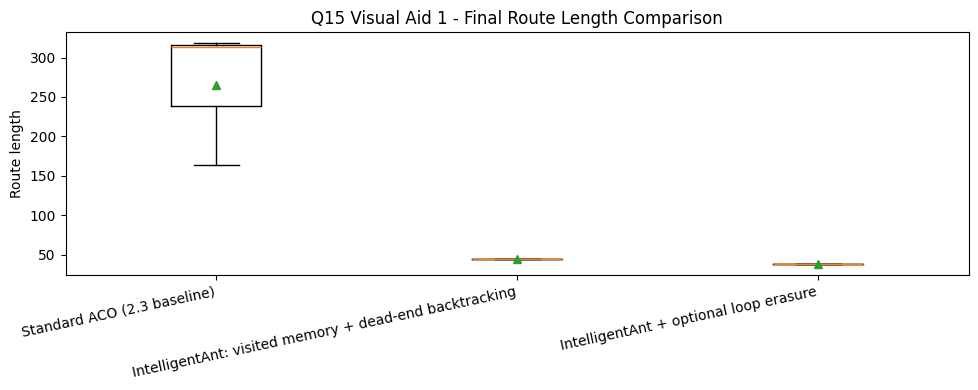

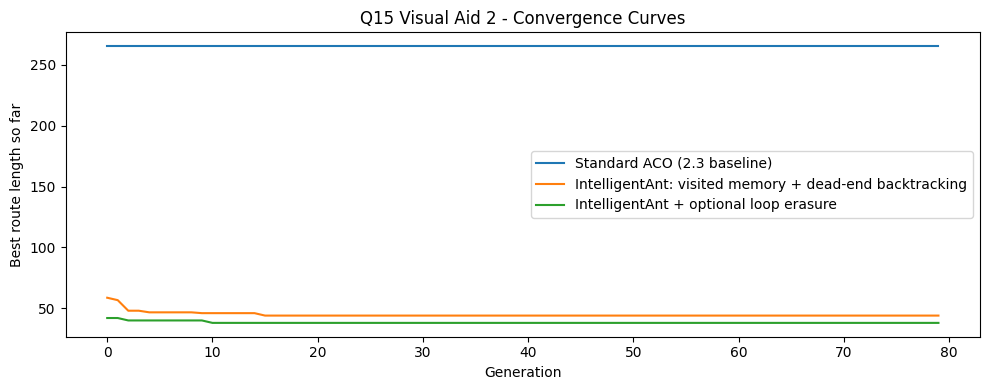

Ready reading maze file ./../data/easy_maze.txt


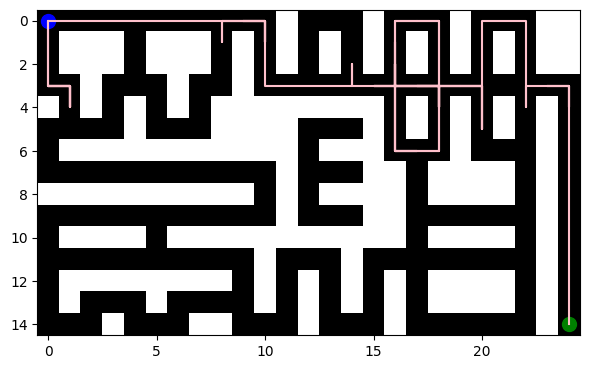

Baseline length: 314


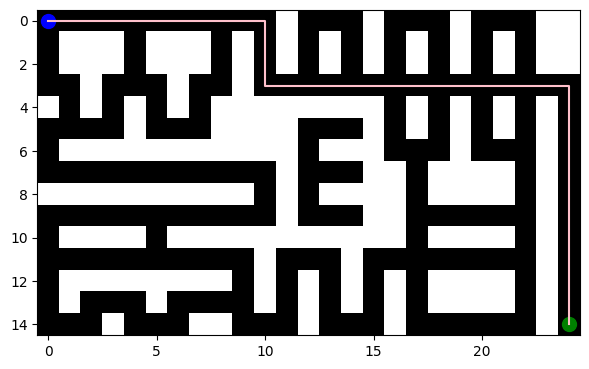

Core improvements length: 38


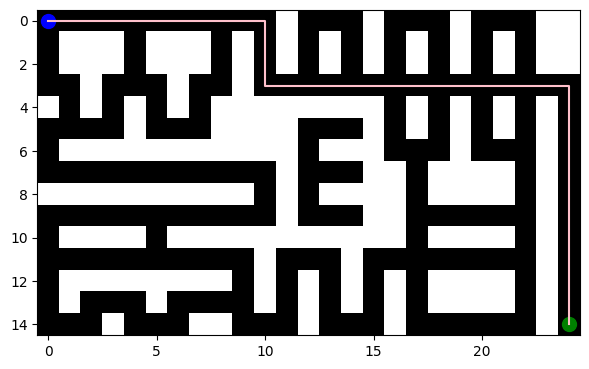

Core + optional loop erasure length: 38


In [72]:
# Q15 visual aids: baseline vs new intelligent-ant variants on Easy maze

spec_q15 = PathSpecification.read_coordinates("./../data/easy_coordinates.txt")
maze_q15 = Maze.create_maze("./../data/easy_maze.txt")

# Shared evaluation settings (same for all variants for fair comparison)
q15_ants = 45
q15_generations = 80
q15_q = 900
q15_evaporation = 0.15
q15_patience = 20
q15_max_steps = 350
q15_seeds = [1, 2, 3]


def route_reaches_end(route, spec):
    """Verify route validity by replaying steps from start.

    Args:
        route (Route): Candidate route returned by ACO.
        spec (PathSpecification): Expected start/end coordinates.

    Returns:
        bool: True if route terminates exactly at the target coordinate.
    """
    pos = spec.get_start()
    for direction in route.get_route():
        pos = pos.add_direction(direction)
    return pos == spec.get_end()


def fill_history(history, total_generations):
    """Normalize history length for fair cross-run convergence plots.

    Args:
        history (list[float]): Best-so-far lengths produced by one run.
        total_generations (int): Target history length.

    Returns:
        np.ndarray: Length-normalized series with NaN handling.
    """
    arr = np.array(history, dtype=float)
    if len(arr) < total_generations:
        pad = np.full(total_generations - len(arr), np.nan)
        arr = np.concatenate([arr, pad])

    # Forward fill for smoother convergence curves.
    for i in range(1, len(arr)):
        if np.isnan(arr[i]) and not np.isnan(arr[i - 1]):
            arr[i] = arr[i - 1]

    # Backfill early NaNs if a first valid value exists.
    valid = np.where(~np.isnan(arr))[0]
    if len(valid) > 0:
        first = valid[0]
        arr[:first] = arr[first]

    return arr


def run_variant(name, ant_class, seeds, use_dead_end_memory=None, use_loop_erasure=None):
    """Execute one algorithm variant across several random seeds.

    Args:
        name (str): Label used in plots/tables.
        ant_class (type): Ant class used by ACO.
        seeds (list[int]): Random seeds for repeated trials.
        use_dead_end_memory (bool | None): Optional toggle for intelligent ant memory.
        use_loop_erasure (bool | None): Optional toggle for route loop erasure.

    Returns:
        dict: Variant label, per-seed final lengths, and per-seed convergence histories.
    """
    lengths = []
    histories = []

    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)

        maze = maze_q15

        if use_dead_end_memory is not None:
            maze.use_dead_end_memory = use_dead_end_memory
        if use_loop_erasure is not None:
            maze.use_loop_erasure = use_loop_erasure

        aco = AntColonyOptimization(
            maze=maze,
            ants_per_gen=q15_ants,
            generations=q15_generations,
            q=q15_q,
            evaporation=q15_evaporation,
            convergence_patience=q15_patience,
            max_steps_per_ant=q15_max_steps,
            ant_class=ant_class,
        )

        route, history = aco.find_shortest_route(spec_q15, return_history=True)
        if route_reaches_end(route, spec_q15):
            lengths.append(route.size())
        else:
            lengths.append(np.nan)

        histories.append(fill_history(history, q15_generations))

    return {
        "name": name,
        "lengths": np.array(lengths, dtype=float),
        "histories": np.array(histories, dtype=float),
    }


baseline_res = run_variant(
    "Standard ACO (2.3 baseline)",
    StandardAnt,
    q15_seeds,
)

core_improvements_res = run_variant(
    "IntelligentAnt: visited memory + dead-end backtracking",
    IntelligentAnt,
    q15_seeds,
    use_dead_end_memory=True,
    use_loop_erasure=False,
)

optional_loop_res = run_variant(
    "IntelligentAnt + optional loop erasure",
    IntelligentAnt,
    q15_seeds,
    use_dead_end_memory=True,
    use_loop_erasure=True,
)

all_results = [baseline_res, core_improvements_res, optional_loop_res]

# Print concise numeric summary before plotting to support report discussion.
print("Q15 summary (lower route length is better):")
for result in all_results:
    valid = result["lengths"][~np.isnan(result["lengths"])]
    success = len(valid)
    total = len(q15_seeds)

    if success == 0:
        print(f"- {result['name']}: success 0/{total}, no successful routes for this setup")
    else:
        print(
            f"- {result['name']}: success {success}/{total}, "
            f"mean={np.mean(valid):.1f}, median={np.median(valid):.1f}, best={np.min(valid):.1f}"
        )

# Visual aid 1: route length distribution across seeds (successful runs only)
plot_results = [res for res in all_results if np.sum(~np.isnan(res["lengths"])) > 0]
if len(plot_results) > 0:
    plt.figure(figsize=(10, 4))
    box_data = [res["lengths"][~np.isnan(res["lengths"])] for res in plot_results]
    labels = [res["name"] for res in plot_results]
    plt.boxplot(box_data, tick_labels=labels, showmeans=True)
    plt.xticks(rotation=12, ha="right")
    plt.ylabel("Route length")
    plt.title("Q15 Visual Aid 1 - Final Route Length Comparison")
    plt.tight_layout()
    plt.show()
else:
    print("Visual aid 1 skipped: no successful routes in any variant.")

# Visual aid 2: average convergence of best-so-far route length per generation
plt.figure(figsize=(10, 4))
plotted_any = False
for result in all_results:
    histories = result["histories"]
    if np.all(np.isnan(histories)):
        continue

    curve = np.nanmean(histories, axis=0)
    if np.all(np.isnan(curve)):
        continue

    plt.plot(curve, label=result["name"])
    plotted_any = True

if plotted_any:
    plt.xlabel("Generation")
    plt.ylabel("Best route length so far")
    plt.title("Q15 Visual Aid 2 - Convergence Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    plt.close()
    print("Visual aid 2 skipped: no convergence history available.")

# Visual aid 3: qualitative path comparison using one fixed seed.
plot_seed = 2

# Baseline route
random.seed(plot_seed)
np.random.seed(plot_seed)
maze_baseline = maze_q15
aco_baseline = AntColonyOptimization(
    maze_baseline,
    q15_ants,
    q15_generations,
    q15_q,
    q15_evaporation,
    q15_patience,
    max_steps_per_ant=q15_max_steps,
    ant_class=StandardAnt,
)
route_baseline = aco_baseline.find_shortest_route(spec_q15)

# Core improvements: visited memory + backtracking
random.seed(plot_seed)
np.random.seed(plot_seed)
maze_core = maze_q15
maze_core.use_dead_end_memory = True
maze_core.use_loop_erasure = False
aco_core = AntColonyOptimization(
    maze_core,
    q15_ants,
    q15_generations,
    q15_q,
    q15_evaporation,
    q15_patience,
    max_steps_per_ant=q15_max_steps,
    ant_class=IntelligentAnt,
)
route_core = aco_core.find_shortest_route(spec_q15)

# Same intelligent ant + optional loop-erasure toggle
random.seed(plot_seed)
np.random.seed(plot_seed)
maze_loop = Maze.create_maze("./../data/easy_maze.txt")
maze_loop.use_dead_end_memory = True
maze_loop.use_loop_erasure = True
aco_loop = AntColonyOptimization(
    maze_loop,
    q15_ants,
    q15_generations,
    q15_q,
    q15_evaporation,
    q15_patience,
    max_steps_per_ant=q15_max_steps,
    ant_class=IntelligentAnt,
)
route_loop = aco_loop.find_shortest_route(spec_q15)

vis_maze = maze_q15

Visualizer.visualize_individual_path(vis_maze, route_baseline, spec_q15)
print("Baseline length:", route_baseline.size())

Visualizer.visualize_individual_path(vis_maze, route_core, spec_q15)
print("Core improvements length:", route_core.size())

Visualizer.visualize_individual_path(vis_maze, route_loop, spec_q15)
print("Core + optional loop erasure length:", route_loop.size())


In [73]:
#Tests for Q15 experiment cell


#Test 1: containers exist
assert baseline_res is not None, "baseline_res missing"
assert core_improvements_res is not None, "core_improvements_res missing"
assert optional_loop_res is not None, "optional_loop_res missing"

print("Test 1 passed. Q15 result objects exist.")

#Test 2: expected keys exist
for result in all_results:
    assert "name" in result, "Missing 'name' key"
    assert "lengths" in result, "Missing 'lengths' key"
    assert "histories" in result, "Missing 'histories' key"

print("Test 2 passed. Expected keys exist.")

#Test 3: number of runs matches number of seeds
for result in all_results:
    assert len(result["lengths"]) == len(q15_seeds), "Lengths count does not match seeds"
    assert len(result["histories"]) == len(q15_seeds), "Histories count does not match seeds"

print("Test 3 passed. Each variant stores one result per seed.")

Test 1 passed. Q15 result objects exist.
Test 2 passed. Expected keys exist.
Test 3 passed. Each variant stores one result per seed.


In Question 12, we identified **dead-ends** and **circular passages/loops** as hard maze features.
For Question 15, we use two biologically-inspired online improvements that do **not** use goal-direction information.

**Improvement 1: visited-set memory (no revisits in forward exploration)**
- Problem addressed: ants repeatedly revisiting the same nodes and wasting steps in loops.
- Mechanism:
  - each ant stores a memory set of visited coordinates,
  - forward exploration is restricted to unseen neighbors only.
- Effect: loops are prevented during route construction, not only corrected afterwards.

**Improvement 2: dead-end backtracking with path memory**
- Problem addressed: visited-set exploration can get stuck at dead-ends.
- Mechanism:
  - when all neighbors are already seen, the ant backtracks along its stored path,
  - it returns to earlier branching points and continues exploring unseen branches.
- Effect: robust exploration in complex mazes while still using only local memory.

**Optional mechanism (kept as parameter): loop erasure**
- We keep `use_loop_erasure` as an optional post-processing toggle.
- This can simplify reinforced routes, but it is not required for the core intelligence mechanism.
- Initially, it was part of the main improvements, but after a discussion with the teaching assistants, we realised that it wasn't making the ants more intelligent, but it was helping with the reinforcement of pheromones, as the loops were not included in the final route.
- The improvements are still noticable, especially in the presence of many dead-ends, given that a dead-end will be considered a loop, it will ensure that no pheromones will be stored on that part of the path. Thus, the next ants will have a smaller probability to choose that dead-end from it's start.

**NOTE:**We consider that any of the improvements cannot be considered as cheating: no heuristic about the exit location is used and decisions remain local and stochastic

**Visual aids**
The code cell above compares:
1. Baseline Standard ACO,
2. Improvement 1 + 2 (memory + backtracking),
3. Improvement 1 + 2 with optional loop erasure.

It provides:
- a distribution plot of final route lengths across multiple seeds,
- convergence curves over generations,
- route visualizations for a fixed seed.

**Discussion on the results**
We compared three variants on the Easy maze using 3 random seeds and 80 generations. All variants reached the goal in 3/3 runs, but route quality differed strongly:
- Standard ACO (2.3 baseline): mean=265.3, median=314.0, best=164.0
- IntelligentAnt (visited-memory + dead-end backtracking): mean=44.0, median=44.0, best=44.0
- IntelligentAnt + optional loop erasure: mean=38.0, median=38.0, best=38.0

This shows a large improvement over baseline: memory + backtracking reduces average route length by about 83%, and adding loop erasure improves a further ~14% relative to the memory+backtracking variant (44 -> 38).

### 2.5 Parameter Optimization

#### Question 16

In [74]:
# We use the improved ant from Q15 (visited-set memory + dead-end backtracking).
# For Q16 we keep this behavior fixed and only compare hyper-parameter settings.

MAZE_SPECS = {
    "easy": {
        "maze_file": "./../data/easy_maze.txt",
        "coord_file": "./../data/easy_coordinates.txt",
    },
    "medium": {
        "maze_file": "./../data/medium_maze.txt",
        "coord_file": "./../data/medium_coordinates.txt",
    },
    "hard": {
        "maze_file": "./../data/hard_maze.txt",
        "coord_file": "./../data/hard_coordinates.txt",
    },
}

Q16_MAZES = ["easy", "medium", "hard"]
Q16_SEEDS = [1, 7, 19]  # Same seeds for every config to keep comparison fair.

# Three configurations per maze: faster / balanced / quality-focused budget.
Q16_CONFIGS = {
    "easy": {
        "E_fast": {
            "ants_per_generation": 14,
            "max_generations": 40,
            "q": 700,
            "evaporation": 0.28,
            "convergence_patience": 8,
            "no_success_patience": 6,
            "max_steps_per_ant": 220,
        },
        "E_balanced": {
            "ants_per_generation": 22,
            "max_generations": 50,
            "q": 1100,
            "evaporation": 0.20,
            "convergence_patience": 12,
            "no_success_patience": 8,
            "max_steps_per_ant": 320,
        },
        "E_quality": {
            "ants_per_generation": 30,
            "max_generations": 60,
            "q": 1700,
            "evaporation": 0.14,
            "convergence_patience": 18,
            "no_success_patience": 12,
            "max_steps_per_ant": 450,
        },
    },
    "medium": {
        "M_fast": {
            "ants_per_generation": 15,
            "max_generations": 55,
            "q": 1400,
            "evaporation": 0.24,
            "convergence_patience": 10,
            "no_success_patience": 8,
            "max_steps_per_ant": 600,
        },
        "M_balanced": {
            "ants_per_generation": 25,
            "max_generations": 70,
            "q": 2100,
            "evaporation": 0.17,
            "convergence_patience": 15,
            "no_success_patience": 10,
            "max_steps_per_ant": 850,
        },
        "M_quality": {
            "ants_per_generation": 30,
            "max_generations": 85,
            "q": 2900,
            "evaporation": 0.10,
            "convergence_patience": 20,
            "no_success_patience": 14,
            "max_steps_per_ant": 1200,
        },
    },
    "hard": {
        "H_fast": {
            "ants_per_generation": 20,
            "max_generations": 50,
            "q": 2000,
            "evaporation": 0.22,
            "convergence_patience": 15,
            "no_success_patience": 12,
            "max_steps_per_ant": 1500,
        },
        "H_balanced": {
            "ants_per_generation": 25,
            "max_generations": 75,
            "q": 3000,
            "evaporation": 0.15,
            "convergence_patience": 20,
            "no_success_patience": 20,
            "max_steps_per_ant": 2000,
        },
        "H_quality": {
            "ants_per_generation": 36,
            "max_generations": 100,
            "q": 5000,
            "evaporation": 0.10,
            "convergence_patience": 25,
            "no_success_patience": 25,
            "max_steps_per_ant": 2800,
        },
    },
}

if not all(len(Q16_CONFIGS[name]) == 3 for name in Q16_MAZES):
    raise ValueError("3 configurations per maze.")


# We will use caches to avoid re-reading the same files many times
_MAZE_CACHE = {}
_SPEC_CACHE = {}
_Q16_CACHE = {}


def route_reaches_end(route, spec):
    """Check whether a route truly ends at the expected target coordinate.

    Args:
        route (Route): Route returned by one ACO run.
        spec (PathSpecification): Start/end specification for this maze.

    Returns:
        bool: True if replaying the route reaches spec.get_end().
    """
    position = spec.get_start()
    for direction in route.get_route():
        position = position.add_direction(direction)
    return position == spec.get_end()


def clone_maze_cached(maze_file):
    """Create a fresh Maze object from a cached wall template.

    Args:
        maze_file (str): Path to the maze text file.

    Returns:
        Maze: New Maze instance with copied wall matrix.
    """
    if maze_file not in _MAZE_CACHE:
        template = Maze.create_maze(maze_file)
        _MAZE_CACHE[maze_file] = {
            "walls": [col[:] for col in template.walls],
            "width": template.get_width(),
            "length": template.get_length(),
        }

    cached = _MAZE_CACHE[maze_file]
    walls_copy = [col[:] for col in cached["walls"]]
    return Maze(walls_copy, cached["width"], cached["length"])


def get_spec_cached(coord_file):
    """Load and cache one coordinate specification file.

    Args:
        coord_file (str): Path to start/end coordinate file.

    Returns:
        PathSpecification: Parsed coordinate specification.
    """
    if coord_file not in _SPEC_CACHE:
        _SPEC_CACHE[coord_file] = PathSpecification.read_coordinates(coord_file)
    return _SPEC_CACHE[coord_file]


def infer_stop_reason(history, params):
    """Infer why the run ended (max generations, patience, or no-success stop).

    Args:
        history (list[float]): Best-so-far history from ACO run.
        params (dict): Hyper-parameters used for that run.

    Returns:
        str: Estimated stop reason label.
    """
    stop_gen = len(history)
    max_gen = params["max_generations"]
    if stop_gen >= max_gen:
        return "max_generations"

    arr = np.array(history, dtype=float)
    if len(arr) == 0:
        return "early_stop"

    # If every recorded point is NaN, no ant reached the goal for the whole run.
    if np.all(np.isnan(arr)):
        return "no_success_patience"

    # Count trailing plateau length on valid (non-NaN) values.
    valid = arr[~np.isnan(arr)]
    trailing_no_improve = 0
    for i in range(len(valid) - 1, 0, -1):
        if valid[i] == valid[i - 1]:
            trailing_no_improve += 1
        else:
            break

    if trailing_no_improve >= params["convergence_patience"]:
        return "convergence_patience"

    return "early_stop"


def run_single_q16(maze_file, coord_file, params, seed):
    """Run one seeded ACO trial and collect raw metrics.

    Args:
        maze_file (str): Maze file path.
        coord_file (str): Coordinate file path.
        params (dict): One Q16 configuration dictionary.
        seed (int): RNG seed used for reproducibility.

    Returns:
        dict: Success flag, route length, runtime, generation count, history, stop reason.
    """
    random.seed(seed)
    np.random.seed(seed)

    maze = clone_maze_cached(maze_file)
    spec = get_spec_cached(coord_file)

    # Keep intelligent-ant behavior fixed during tuning.
    maze.use_dead_end_memory = True
    maze.use_loop_erasure = True

    aco = AntColonyOptimization(
        maze=maze,
        ants_per_gen=params["ants_per_generation"],
        generations=params["max_generations"],
        q=params["q"],
        evaporation=params["evaporation"],
        convergence_patience=params["convergence_patience"],
        no_success_patience=params["no_success_patience"],
        max_steps_per_ant=params["max_steps_per_ant"],
        ant_class=IntelligentAnt,
    )

    t0 = time.time()
    route, history = aco.find_shortest_route(spec, return_history=True)
    elapsed = time.time() - t0

    success = route_reaches_end(route, spec)

    return {
        "seed": seed,
        "success": bool(success),
        "route_length": route.size() if success else np.nan,
        "convergence_generations": len(history),
        "runtime_sec": elapsed,
        "history": list(history),
        "stop_reason": infer_stop_reason(history, params),
    }


def evaluate_config_q16(maze_name, cfg_name, params, seeds):
    """Evaluate one configuration across multiple seeds.

    Args:
        maze_name (str): Maze key in MAZE_SPECS.
        cfg_name (str): Configuration label (e.g., E_fast).
        params (dict): Hyper-parameter configuration.
        seeds (list[int]): List of seeds to average over.

    Returns:
        dict: Aggregated metrics plus per-seed run details.
    """
    params_key = tuple(sorted(params.items()))
    key = (maze_name, cfg_name, params_key, tuple(seeds))

    if key in _Q16_CACHE:
        return dict(_Q16_CACHE[key])

    files = MAZE_SPECS[maze_name]
    runs = [run_single_q16(files["maze_file"], files["coord_file"], params, s) for s in seeds]

    success_flags = np.array([r["success"] for r in runs], dtype=float)
    lengths = np.array([r["route_length"] for r in runs], dtype=float)
    conv = np.array([r["convergence_generations"] for r in runs], dtype=float)
    runtimes = np.array([r["runtime_sec"] for r in runs], dtype=float)

    valid_lengths = lengths[~np.isnan(lengths)]

    metrics = {
        "success_rate": float(np.mean(success_flags)),
        "mean_route_length": float(np.mean(valid_lengths)) if len(valid_lengths) > 0 else np.nan,
        "std_route_length": float(np.std(valid_lengths)) if len(valid_lengths) > 0 else np.nan,
        "best_route_length": float(np.min(valid_lengths)) if len(valid_lengths) > 0 else np.nan,
        "mean_convergence_generations": float(np.mean(conv)),
        "mean_runtime_sec": float(np.mean(runtimes)),
        "runs": runs,
    }
    _Q16_CACHE[key] = dict(metrics)
    return metrics


def config_score(metrics):
    """Compute one ranking score for comparing configurations. We use the score later to choose the optimal configuration

    Args:
        metrics (dict): Aggregated metrics returned by evaluate_config_q16.

    Returns:
        float: Lower-is-better score with strong failure penalty.
    """
    fail_penalty = 10000.0 * (1.0 - metrics["success_rate"])
    length_term = 0.0 if np.isnan(metrics["mean_route_length"]) else metrics["mean_route_length"] / 10.0
    convergence_term = 0.5 * metrics["mean_convergence_generations"]
    return fail_penalty + length_term + convergence_term

def config_rank_key(record):
    """Stable ordering for reproducible best-config selection."""
    return (record["score"], record["mean_convergence_generations"], record["config"])



# Run all Q16 experiments.
q16_start = time.time()
q16_results = {maze_name: [] for maze_name in Q16_MAZES}

print("Q16 experiment design:")
print(f"- mazes: {Q16_MAZES}")
print("- configurations per maze: 3")
print(f"- seeds per configuration: {Q16_SEEDS}")

for maze_name in Q16_MAZES:
    print()
    print(f"{maze_name.upper()}:")
    for cfg_name, params in Q16_CONFIGS[maze_name].items():
        metrics = evaluate_config_q16(maze_name, cfg_name, params, Q16_SEEDS)

        # We keep both raw params and metrics together for later plotting
        record = {
            "maze": maze_name,
            "config": cfg_name,
            "params": dict(params),
            **metrics,
        }
        record["score"] = config_score(record)
        q16_results[maze_name].append(record)

    # Print ranked summary for this maze.
    ordered = sorted(q16_results[maze_name], key=config_rank_key)

    for r in ordered:
        mean_len_str = "nan" if np.isnan(r["mean_route_length"]) else f"{r['mean_route_length']:.1f}"
        best_len_str = "nan" if np.isnan(r["best_route_length"]) else f"{r['best_route_length']:.1f}"
        print(
            f"- {r['config']}: success={r['success_rate']:.2f}, "
            f"mean_len={mean_len_str}, best_len={best_len_str}, "
            f"mean_conv_gen={r['mean_convergence_generations']:.1f}, "
            f"mean_time={r['mean_runtime_sec']:.2f}s, score={r['score']:.1f}"
        )


# One final configuration per maze for Q17/Q18.
q16_best_records = {}
reported_params_q16 = {}
for maze_name in Q16_MAZES:
    best = sorted(q16_results[maze_name], key=config_rank_key)[0]
    q16_best_records[maze_name] = best
    reported_params_q16[maze_name] = dict(best["params"])

print()
print("Selected parameter set per maze (reported_params_q16):")
for maze_name in Q16_MAZES:
    p = reported_params_q16[maze_name]
    print(
        f"- {maze_name.upper()}: ants={p['ants_per_generation']}, "
        f"max_gens={p['max_generations']}, q={p['q']}, evap={p['evaporation']}, "
        f"conv_patience={p['convergence_patience']}, no_success={p['no_success_patience']}, "
        f"max_steps={p['max_steps_per_ant']}"
    )

q16_records_flat = [r for maze_name in Q16_MAZES for r in q16_results[maze_name]]



Q16 experiment design:
- mazes: ['easy', 'medium', 'hard']
- configurations per maze: 3
- seeds per configuration: [1, 7, 19]

EASY:
Ready reading maze file ./../data/easy_maze.txt
- E_fast: success=1.00, mean_len=44.0, best_len=38.0, mean_conv_gen=11.7, mean_time=0.35s, score=10.2
- E_balanced: success=1.00, mean_len=40.0, best_len=38.0, mean_conv_gen=15.0, mean_time=0.95s, score=11.5
- E_quality: success=1.00, mean_len=38.0, best_len=38.0, mean_conv_gen=22.0, mean_time=1.96s, score=14.8

MEDIUM:
Ready reading maze file ./../data/medium_maze.txt
- M_fast: success=1.00, mean_len=203.7, best_len=185.0, mean_conv_gen=15.3, mean_time=1.77s, score=28.0
- M_quality: success=1.00, mean_len=183.0, best_len=177.0, mean_conv_gen=30.7, mean_time=14.27s, score=33.6
- M_balanced: success=1.00, mean_len=173.0, best_len=159.0, mean_conv_gen=38.3, mean_time=10.20s, score=36.5

HARD:
Ready reading maze file ./../data/hard_maze.txt
- H_balanced: success=1.00, mean_len=936.3, best_len=903.0, mean_conv_g

In [75]:
#Tests for Q16 parameter search

#Test 1: expected mazes exist in results
for maze_name in Q16_MAZES:
    assert maze_name in q16_results, f"{maze_name} missing from q16_results"
    assert len(q16_results[maze_name]) == 3, f"{maze_name} should have exactly 3 configurations"

print("Test 1 passed. Q16_results has 3 configs per maze.")


#Test 2: each config record has core fields
for maze_name in Q16_MAZES:
    for record in q16_results[maze_name]:
        assert "config" in record, "Missing config label"
        assert "params" in record, "Missing params"
        assert "success_rate" in record, "Missing success_rate"
        assert "mean_convergence_generations" in record, "Missing convergence metric"
        assert "mean_runtime_sec" in record, "Missing runtime metric"
        assert "score" in record, "Missing score"

print("Test 2 passed. Each Q16 record contains expected fields.")


#Test 3: selected best params exist for each maze
for maze_name in Q16_MAZES:
    assert maze_name in reported_params_q16, f"Missing selected params for {maze_name}"
    params = reported_params_q16[maze_name]
    assert "ants_per_generation" in params, "Missing ants_per_generation"
    assert "max_generations" in params, "Missing max_generations"
    assert "q" in params, "Missing q"
    assert "evaporation" in params, "Missing evaporation"

print("Test 3 passed. Reported_params_q16 contains selected parameter sets.")

Test 1 passed. Q16_results has 3 configs per maze.
Test 2 passed. Each Q16 record contains expected fields.
Test 3 passed. Reported_params_q16 contains selected parameter sets.


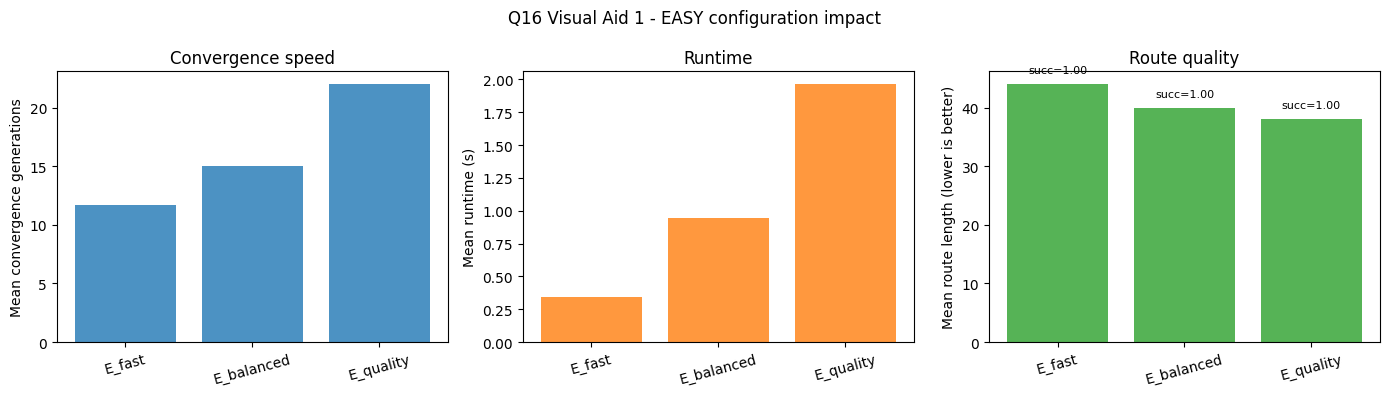

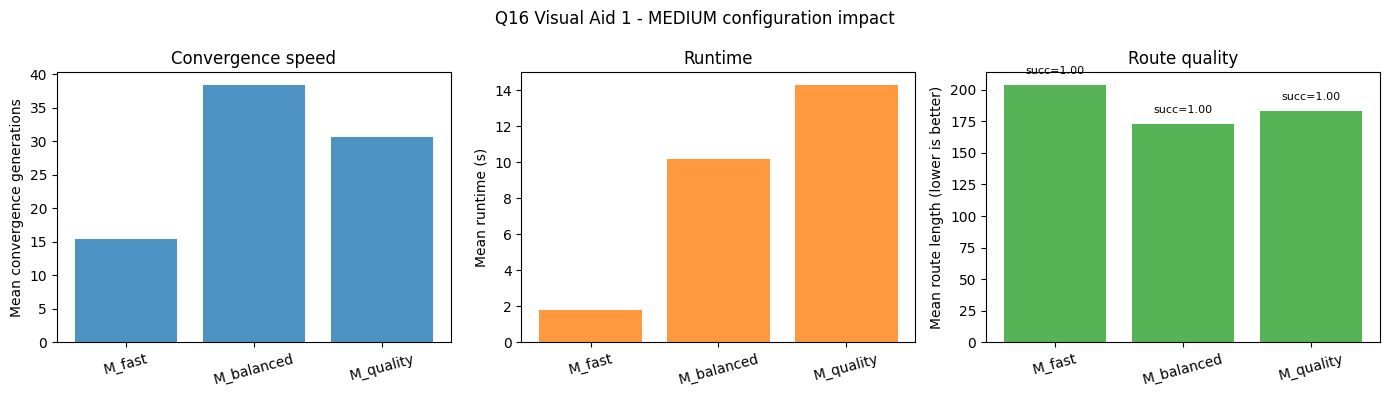

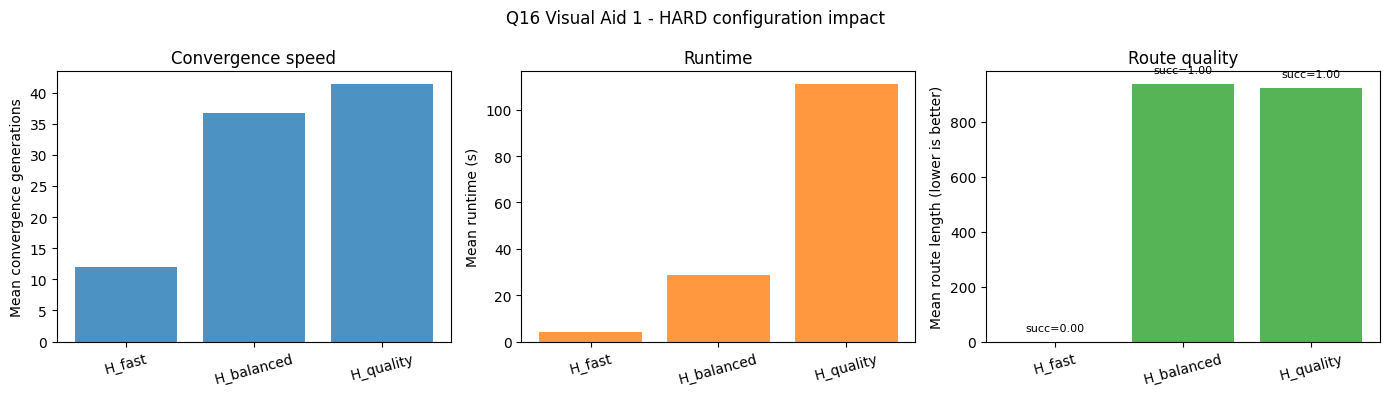

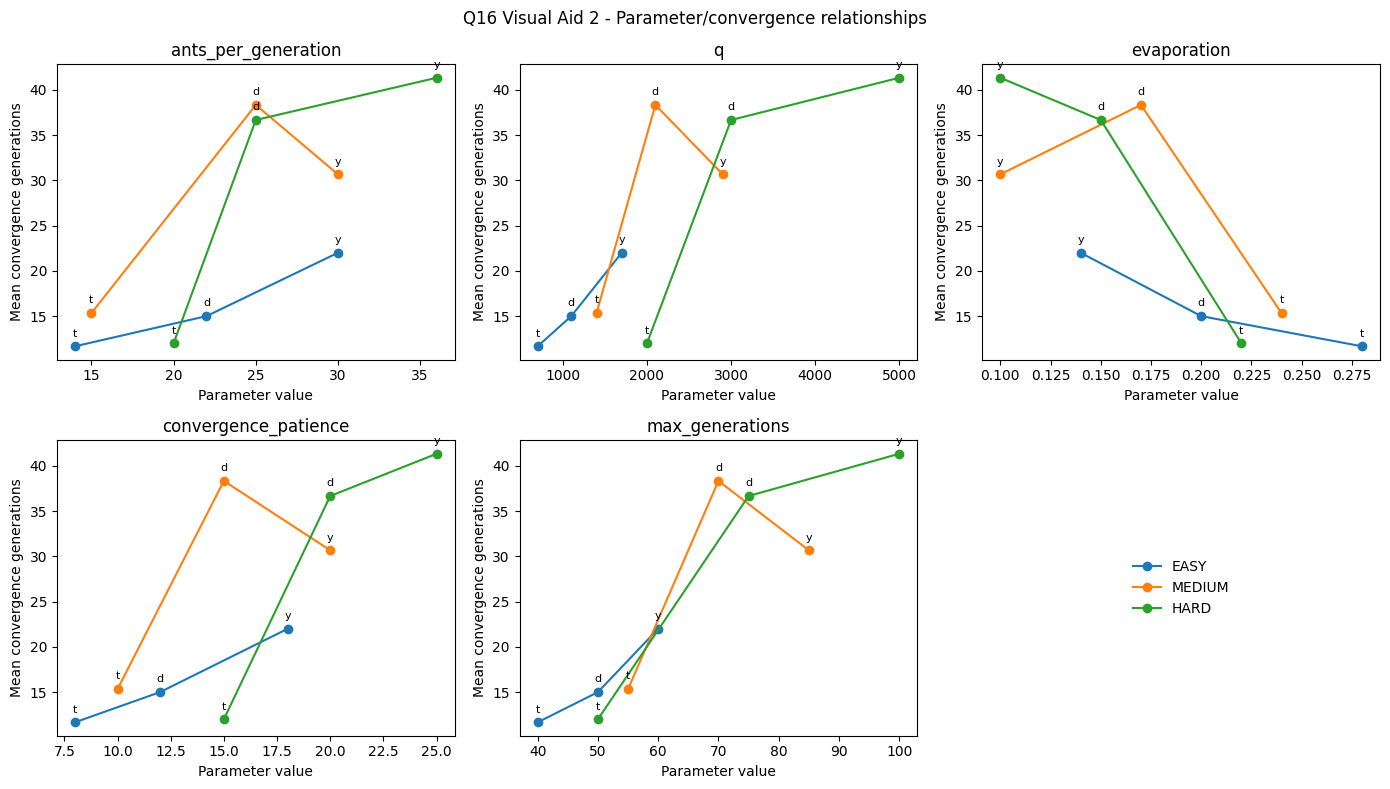

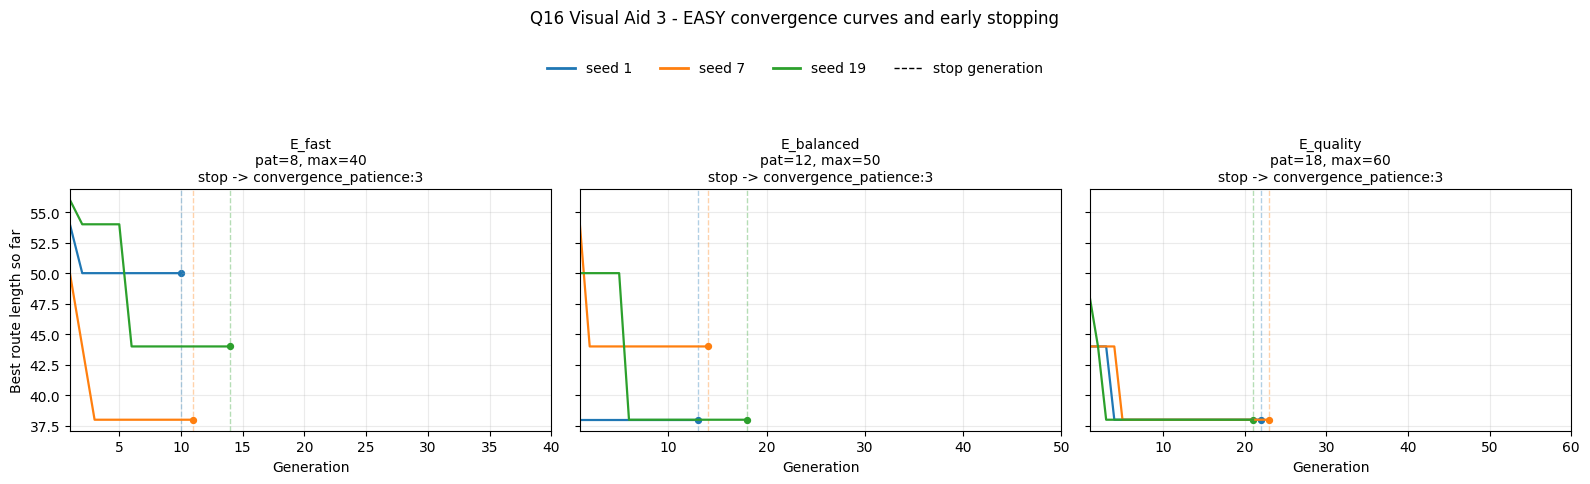

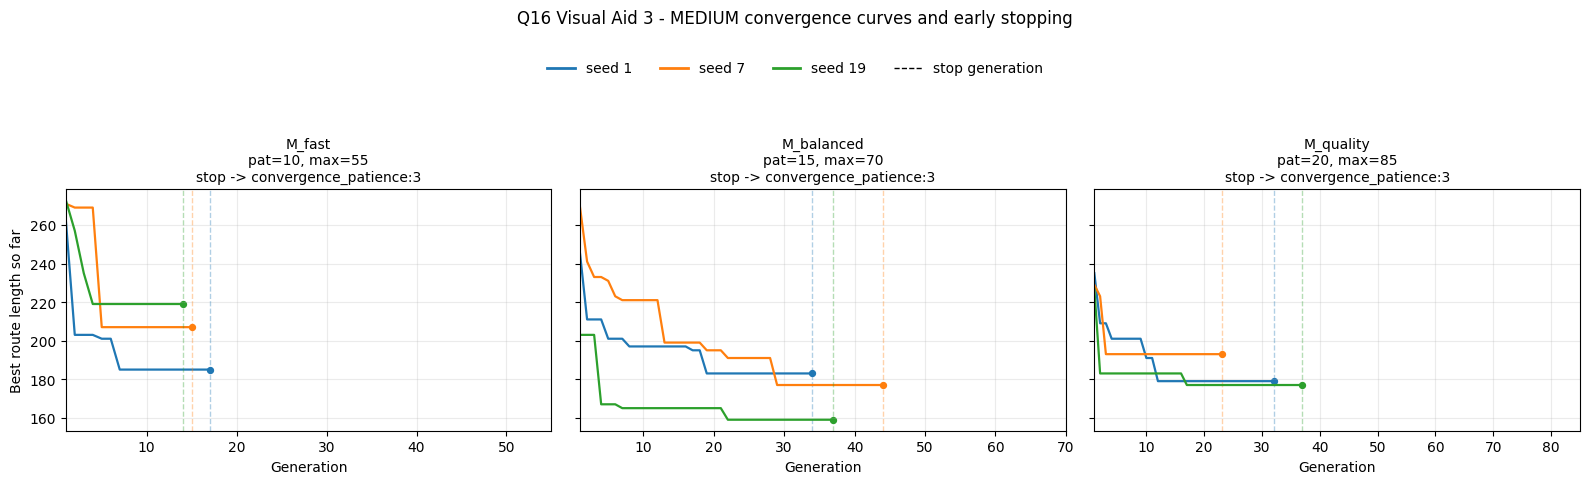

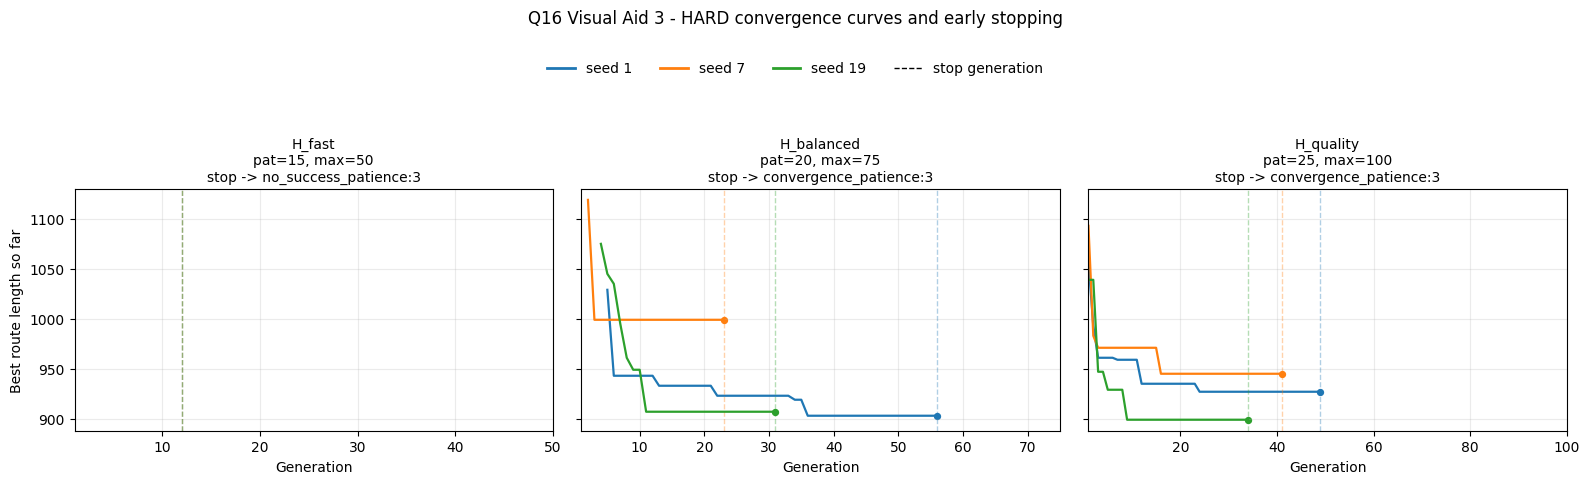

In [76]:
#Visualisation cell for Question 16
# Visual 1: compare convergence speed, runtime, and route quality per maze.
for maze_name in Q16_MAZES:
    records = q16_results[maze_name]
    labels = [r["config"] for r in records]
    x = np.arange(len(records))

    conv_vals = [r["mean_convergence_generations"] for r in records]
    runtime_vals = [r["mean_runtime_sec"] for r in records]
    length_vals = [r["mean_route_length"] if not np.isnan(r["mean_route_length"]) else 0.0 for r in records]
    success_vals = [r["success_rate"] for r in records]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].bar(x, conv_vals, color="tab:blue", alpha=0.8)
    axes[0].set_title("Convergence speed")
    axes[0].set_ylabel("Mean convergence generations")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=15)

    axes[1].bar(x, runtime_vals, color="tab:orange", alpha=0.8)
    axes[1].set_title("Runtime")
    axes[1].set_ylabel("Mean runtime (s)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=15)

    bars = axes[2].bar(x, length_vals, color="tab:green", alpha=0.8)
    # Failed configs are shown with hatch to make them visually obvious.
    for i, r in enumerate(records):
        if np.isnan(r["mean_route_length"]):
            bars[i].set_hatch("//")
            bars[i].set_alpha(0.4)

    axes[2].set_title("Route quality")
    axes[2].set_ylabel("Mean route length (lower is better)")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels, rotation=15)

    for i, succ in enumerate(success_vals):
        axes[2].annotate(
            f"succ={succ:.2f}",
            (i, length_vals[i]),
            textcoords="offset points",
            xytext=(0, 8),
            ha="center",
            fontsize=8,
        )

    fig.suptitle(f"Q16 Visual Aid 1 - {maze_name.upper()} configuration impact")
    plt.tight_layout()
    plt.show()


# Visual 2: show relationship between each parameter and convergence speed.
relationship_keys = [
    "ants_per_generation",
    "q",
    "evaporation",
    "convergence_patience",
    "max_generations",
]

colors = {"easy": "tab:blue", "medium": "tab:orange", "hard": "tab:green"}
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, key in enumerate(relationship_keys):
    ax = axes[i]
    for maze_name in Q16_MAZES:
        records = q16_results[maze_name]
        x = [r["params"][key] for r in records]
        y = [r["mean_convergence_generations"] for r in records]
        labels = [r["config"] for r in records]

        ax.plot(x, y, marker="o", color=colors[maze_name], label=maze_name.upper())
        for xv, yv, cfg in zip(x, y, labels):
            ax.annotate(cfg[-1], (xv, yv), textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)

    ax.set_title(key)
    ax.set_xlabel("Parameter value")
    ax.set_ylabel("Mean convergence generations")

handles, labels = axes[0].get_legend_handles_labels()
axes[5].axis("off")
axes[5].legend(handles, labels, loc="center", frameon=False)

fig.suptitle("Q16 Visual Aid 2 - Parameter/convergence relationships")
plt.tight_layout()
plt.show()


# Visual 3: per-run convergence curves, plus stop markers for early-stop behavior.
Q16_ENABLE_VISUAL_AID_3 = True  # Set False when you just want fast metric reruns.

if Q16_ENABLE_VISUAL_AID_3:
    for maze_name in Q16_MAZES:
        records = q16_results[maze_name]
        fig, axes = plt.subplots(1, len(records), figsize=(16, 5.0), sharey=True)
        if len(records) == 1:
            axes = [axes]

        seed_colors = {seed: plt.cm.tab10(i) for i, seed in enumerate(Q16_SEEDS)}

        for ax, record in zip(axes, records):
            params = record["params"]
            max_gen = params["max_generations"]

            for run in record["runs"]:
                history = np.array(run["history"], dtype=float)
                x = np.arange(1, len(history) + 1)
                seed = run["seed"]
                color = seed_colors[seed]

                valid = ~np.isnan(history)
                if np.any(valid):
                    ax.plot(x[valid], history[valid], color=color, linewidth=1.6)
                    ax.scatter(x[valid][-1], history[valid][-1], color=color, s=18)

                stop_gen = run["convergence_generations"]
                if stop_gen < max_gen:
                    ax.axvline(stop_gen, color=color, linestyle="--", alpha=0.35, linewidth=1.0)

            # Small summary in each subplot showing why runs stopped.
            stop_counts = {}
            for run in record["runs"]:
                reason = run["stop_reason"]
                stop_counts[reason] = stop_counts.get(reason, 0) + 1

            stop_text = ", ".join([f"{k}:{v}" for k, v in stop_counts.items()])
            ax.set_xlim(1, max_gen)
            ax.grid(alpha=0.25)
            ax.set_xlabel("Generation")
            ax.set_title(
                f"{record['config']}\n"
                f"pat={params['convergence_patience']}, max={params['max_generations']}\n"
                f"stop -> {stop_text}",
                fontsize=10,
            )

        axes[0].set_ylabel("Best route length so far")

        legend_handles = [
            plt.Line2D([0], [0], color=seed_colors[s], lw=2, label=f"seed {s}")
            for s in Q16_SEEDS
        ]
        legend_handles.append(
            plt.Line2D([0], [0], color="black", lw=1, linestyle="--", label="stop generation")
        )

        fig.suptitle(f"Q16 Visual Aid 3 - {maze_name.upper()} convergence curves and early stopping", y=0.98)
        fig.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.90),
            ncol=len(legend_handles),
            frameon=False,
        )
        plt.tight_layout(rect=[0, 0.02, 1, 0.82])
        plt.show()

In [77]:
#Tests for Q16 visualization cell

#Test 1: plotting inputs are available
assert len(Q16_MAZES) == 3, "Expected three mazes for Q16"
assert len(relationship_keys) == 5, "Expected five relationship keys"

print("Test 1 passed. Visualization inputs are defined.")

#Test 2: each maze has records ready for plotting
for maze_name in Q16_MAZES:
    assert len(q16_results[maze_name]) > 0, f"No results available for {maze_name} plotting"

print("Test 2 passed. Each maze has records for plotting.")

Test 1 passed. Visualization inputs are defined.
Test 2 passed. Each maze has records for plotting.



**Tuning strategy (budget-aware):**
We used a structured tuning strategy for the final answer to keep the total running time of the notebook reasonable (even though, way more configurations were tested overall, but we aimed to keep this notebook in a reasonable time limit):
- 3 mazes: Easy, Medium, Hard.
- 3 full hyper-parameter configurations per maze (`fast`, `balanced`, `quality`).
- 3 random seeds per configuration (`[1, 7, 19]`).
- Evaluation metrics: success rate, mean route length, mean convergence generations, mean runtime.
- Selection rule: prioritize success rate first, then route quality (length), then speed.
This gives `3 mazes x 3 configs x 3 seeds = 27` total runs, which ensured that we explore some different architecures for the paramterers and run multiple seeds on each to ensure no lucky paths influenced the result.<br><br>

**Discussion on the plots and how we can derive best architecure based on them**

`Visual Aid 1` shows three different behaviors by maze.

- **Easy:** all configs solved all seeds (`success=1.00`). Quality improves from `E_fast` to `E_quality`, but convergence cost also increases .  
- **Medium:** all configs also solved all seeds. Here, `M_fast` converges much earlier but has worse route quality. `M_balanced` has the best quality (`173.0`) but converges much later (`38.3`). Because our ranking score penalizes convergence effort, **`M_fast` is selected** even though it is not the best by length alone.
- **Hard:** `H_fast` is unreliable (`success=0.00`). `H_balanced` and `H_quality` both solve all seeds; `H_quality` is only slightly better in length (`923.7` vs `936.3`) but needs more convergence (`41.3` vs `36.7`) and far more runtime, so `H_balanced` is selected.

`Visual Aid 2` confirms that parameter effects are interaction-based (not strictly monotonic per parameter). Increasing search budget (`ants`, `q`, `max_generations`) can help quality on harder mazes, but it also increases convergence effort and runtime; lower evaporation and higher patience are more useful as maze difficulty grows.

`Visual Aid 3` shows that hard-maze runs typically stop by `convergence_patience` before reaching the hard cap (`max_generations`). This validates that early stopping is active and that `max_generations` is mostly a safety bound.

We also observe that **seeds** really influence how fast our ant will find the end point of the maze. To counter this, we ran the 3 different seeds and used the mean values.<br><br>


**Clearly reported selected hyper-parameters (per maze):**<br>
We created our own score formula to rank the solutions. Initially, the formula also contained the running time of the run ( focusing a lot more on the tradeoff performance/resources - as there is no free lunch in Computer Science), but we decide to drop it, given the unpredictable and hardware-dependent behaviour. We used it to decide the final configurations

| Maze | ants_per_generation | max_generations | q | evaporation | convergence_patience |
|---|---:|---:|---:|---:|---:|
| Easy | 14 | 40 | 700 | 0.28 | 8 |
| Medium | 15 | 55 | 1400 | 0.24 | 10 |
| Hard | 25 | 75 | 3000 | 0.15 | 20 |

(Additional controls used during tuning: `no_success_patience = 6/8/20`- which specifies after how many consecutive tries with no result we should abandon the run, and `max_steps_per_ant = 220/600/2000`- basic feature of the ants to prevent them to wander forever, however, from our experiments we observed that it is crucial to consider a large enough value for it in order for our ants to reach the end of the maze)<br><br>

**Observed impact of hyper-parameter settings on each maze:**
- **Easy maze:** all 3 configs had 100% success. `E_fast` converged fastest but had worse mean length. `E_balanced`/`E_quality` improved mean length to.
- **Medium maze:** all 3 configs had 100% success. `M_fast` was best overall for this maze in our runs , while heavier settings were slower and did not improve route length significantly.
- **Hard maze:** `H_fast` failed (0/3 success), showing that too aggressive low-budget settings are unreliable. `H_balanced` gave the best trade-off, while `H_quality` was slower and had a unsignificant difference in the mean length.



#### Question 17

The mazes gradually increase in both size and complexity. Our Intelligent Ant, however, can manage all of the complex features from any of the presented mazes. 

Based on our Q16 tuning, the preferred settings from Easy to Hard were:
- `ants_per_generation`: `14 -> 15 -> 25`
- `max_generations`: `40 -> 55 -> 75`
- `q`: `700 -> 1400 -> 3000`
- `evaporation`: `0.28 -> 0.24 -> 0.15`
- `convergence_patience`: `8 -> 10 -> 20`

Maze scale also increased strongly (`375 -> 2000 -> 6400` cells), so the search space became much larger.

Interpretation per parameter:
1. `ants_per_generation` increases with complexity because harder mazes benefit from the use of multiple parallel ants each generations - will explore more paths without being affected by the pheromone levels yet.
2. `max_generations` increases because larger mazes require more pheromone-update cycles before stable useful trails emerge, however, from our observations, it is not as sensible as other hyperparameters
3. `q` also increases to strengthen reinforcement on good routes in larger search spaces (larger routes means that we need a larger value to divide them by so the values do not loose meaning)
4. `evaporation` decreases so useful pheromone trails persist longer instead of being forgotten too quickly (which could lead to never finding a path in harder mazes). However, the evaporation also influences how much we want the exploit or explore - a larger evaporation constant will force the following generations to find the path again, while a smaller one will make next generations exploit existing paths
5. `convergence_patience` increases with complexity to avoid stopping too early when improvements are sparse in difficult mazes.
6. `max_steps_per_ant`, which is not one of the 5 original 5 hyper-parameters, however, it is very important in understanding the value range for which the ant is actually capable of finding the solution of the maze. Although the Intelligent Ant does not reuse paths already visited, the Standard Ant's inneficiency can be an important reason to choose a larger max_steps number as it will need to wonder way more in the space of the maze to find a path (also true for the larger mazes). It is also really important when considering the "budget" (time, computational resources) of the ACO run.

In short, as maze complexity grows, good settings shift toward a larger exploration budget and longer pheromone memory. However, there are also other features that a maze can have that would make it more complex/unique ( open areas, dead ends, shortcuts) and it will also influence the choice of hyper parameters.



### 2.6 The Final Route

#### Question 18

Ready reading maze file ./../data/easy_maze.txt
Ready reading maze file ./../data/medium_maze.txt
Ready reading maze file ./../data/hard_maze.txt
Ready reading maze file ./../data/insane_maze.txt
Q18 final-route summary (+ insane efficiency check):
- EASY: success, length=44, gens=14, time=0.45s, file=./../data/Group_33_easy.txt
- MEDIUM: success, length=219, gens=14, time=1.87s, file=./../data/Group_33_medium.txt
- HARD: success, length=907, gens=31, time=24.47s, file=./../data/Group_33_hard.txt
- INSANE: success, length=523, gens=42, time=27.93s, file=(We did not export a file for insane maze as it was not required)


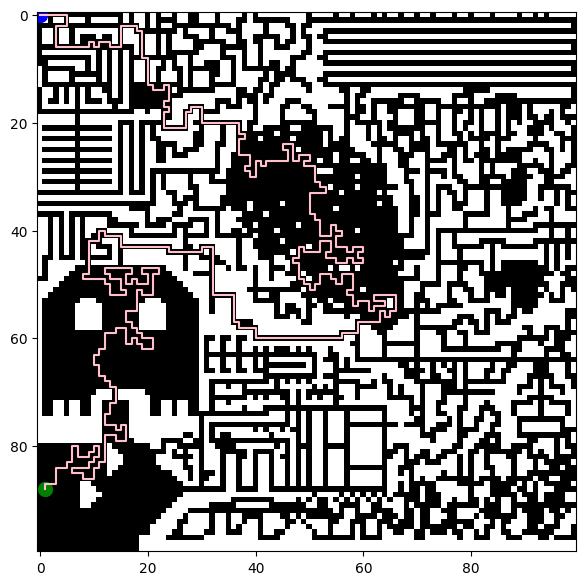

In [78]:
# Q18 - Generate final route files and also test Insane maze efficiency

GROUP_ID = "Group_33"
Q18_OUTPUT_DIR = "./../data"
Q18_SEED = 19

if "reported_params_q16" not in globals():
    raise RuntimeError("Run the Q16 cell first so reported_params_q16 is available.")


q18_results = {}
q18_examples = {}

# We include insane in the run report, but do not export a file for it.
q18_mazes = ["easy", "medium", "hard", "insane"]

for maze_name in q18_mazes:
    if maze_name == "insane":
        maze_file = "./../data/insane_maze.txt"
        coord_file = "./../data/insane_coordinates.txt"
        # No tuned insane params from Q16, so we reuse hard settings.
        params = dict(reported_params_q16["hard"])
    else:
        maze_file = MAZE_SPECS[maze_name]["maze_file"]
        coord_file = MAZE_SPECS[maze_name]["coord_file"]
        params = dict(reported_params_q16[maze_name])

    random.seed(Q18_SEED)
    np.random.seed(Q18_SEED)

    maze = Maze.create_maze(maze_file)
    spec = PathSpecification.read_coordinates(coord_file)

    maze.use_dead_end_memory = True
    maze.use_loop_erasure = True

    aco = AntColonyOptimization(
        maze=maze,
        ants_per_gen=params["ants_per_generation"],
        generations=params["max_generations"],
        q=params["q"],
        evaporation=params["evaporation"],
        convergence_patience=params["convergence_patience"],
        no_success_patience=params["no_success_patience"],
        max_steps_per_ant=params["max_steps_per_ant"],
        ant_class=IntelligentAnt,
    )

    t0 = time.time()
    route, history = aco.find_shortest_route(spec, return_history=True)
    elapsed = time.time() - t0

    success = route_reaches_end(route, spec)

    # Export only easy/medium/hard.
    out_path = f"{Q18_OUTPUT_DIR}/{GROUP_ID}_{maze_name}.txt"
    if success and maze_name != "insane":
        route.write_to_file(out_path)

    q18_results[maze_name] = {
        "success": bool(success),
        "route_length": route.size() if success else np.nan,
        "runtime_sec": elapsed,
        "generations_executed": len(history),
        "output_file": out_path if maze_name != "insane" else "(We did not export a file for insane maze as it was not required)",
    }

    q18_examples[maze_name] = {
        "maze": maze,
        "route": route,
        "spec": spec,
    }


print("Q18 final-route summary (+ insane efficiency check):")
for maze_name in q18_mazes:
    r = q18_results[maze_name]
    if r["success"]:
        print(
            f"- {maze_name.upper()}: success, length={r['route_length']}, "
            f"gens={r['generations_executed']}, time={r['runtime_sec']:.2f}s, "
            f"file={r['output_file']}"
        )
    else:
        print(
            f"- {maze_name.upper()}: FAILED (no valid route). "
            f"gens={r['generations_executed']}, time={r['runtime_sec']:.2f}s"
        )


# Visualize resulting routes for insane maze.
Visualizer.visualize_individual_path(
        q18_examples["insane"]["maze"],
        q18_examples["insane"]["route"],
        q18_examples["insane"]["spec"],
)

    


We included the Insane Maze just as a proof of efficiency for our ACO algorithm. We used the Hard Maze parameters for this run and the results are still encouraging (except open area behaviour).

In [79]:
#Tests for Q18 final routes

#Test 1: all expected maze results exist
for maze_name in ["easy", "medium", "hard", "insane"]:
    assert maze_name in q18_results, f"{maze_name} missing from q18_results"
    assert maze_name in q18_examples, f"{maze_name} missing from q18_examples"
print("Test 1 passed. Q18 result structures exist for all mazes.")


#Test 2: each result has expected field
for maze_name, result in q18_results.items():
    assert "success" in result, f"Missing success field for {maze_name}"
    assert "runtime_sec" in result, f"Missing runtime_sec for {maze_name}"
    assert "generations_executed" in result, f"Missing generations_executed for {maze_name}"
print("Test 2 passed. Each Q18 result contains expected fields.")


#Test 3: if a route succeeded, its route length must be non-negative
for maze_name, result in q18_results.items():
    if result["success"]:
        assert result["route_length"] >= 0, f"Invalid route length for {maze_name}"

print("Test 3 passed. Successful routes have valid lengths.")

Test 1 passed. Q18 result structures exist for all mazes.
Test 2 passed. Each Q18 result contains expected fields.
Test 3 passed. Successful routes have valid lengths.


### 2.7 Synthesis

#### Question 19

In [90]:
# Step 1:synthesis distance matrix

# ACO parameters for building TSP distances on the Hard maze.
# Fast pass; broken pairs (if any) are repaired in Step 2.
syn_ants_per_generation = 8
syn_max_generations = 14
syn_q = 3000
syn_evaporation = 0.10
syn_convergence_patience = 6
syn_no_success_patience = 8
syn_max_steps_per_ant = 2300

# GA parameters for the final ordering step
syn_population_size = 100
syn_ga_generations = 600
syn_x_prob = 0.9
syn_mut_prob = 0.05
syn_random_seed = 1337
syn_elitist = True

# Paths.
syn_maze_file = "./../data/hard_maze.txt"
syn_coordinates_file = "./../data/hard_coordinates.txt"
syn_products_file = "./../data/tsp_products.txt"
syn_generated_tsp_file = "./../data/generated_tsp.pkl"
syn_action_file = "./../data/Group_33_actions_TSP.txt"

# Baseline from Part 1
part1_optimal_tsp_file = "./../data/optimal_tsp"


# Build ACO object.
syn_maze = Maze.create_maze(syn_maze_file)
syn_maze.use_dead_end_memory = True
syn_maze.use_loop_erasure = False

syn_aco = AntColonyOptimization(
    maze=syn_maze,
    ants_per_gen=syn_ants_per_generation,
    generations=syn_max_generations,
    q=syn_q,
    evaporation=syn_evaporation,
    convergence_patience=syn_convergence_patience,
    no_success_patience=syn_no_success_patience,
    max_steps_per_ant=syn_max_steps_per_ant,
    ant_class=IntelligentAnt,
)


syn_tsp_data_raw = TSPData.read_specification(syn_coordinates_file, syn_products_file)

syn_aco_seed = 19
random.seed(syn_aco_seed)
np.random.seed(syn_aco_seed)

syn_tsp_data_raw.calculate_routes(syn_aco)
syn_tsp_data_raw.write_to_file(syn_generated_tsp_file)

print("Generated TSP data saved to:", syn_generated_tsp_file)


Ready reading maze file ./../data/hard_maze.txt
Generated TSP data saved to: ./../data/generated_tsp.pkl


In [ ]:
# Step 2: strict validation and targeted repair of invalid distance routes

# Load the synthesized matrix from Step 1.
syn_tsp_data = TSPData.read_from_file(syn_generated_tsp_file)
syn_check_maze = Maze.create_maze(syn_maze_file)


def strict_route_ok(route, expected_start, expected_end, maze, require_nonzero=False):
    """Validate full route integrity: start, every step legality, and end."""
    if route is None:
        return False, "route is None"

    if route.get_start() != expected_start:
        return False, f"wrong start {route.get_start()} != {expected_start}"

    p = route.get_start()
    if not maze.in_bounds(p):
        return False, f"start out of bounds at {p}"
    if maze.walls[p.get_x()][p.get_y()] == 0:
        return False, f"start on blocked tile at {p}"

    for k, d in enumerate(route.get_route(), start=1):
        p = p.add_direction(d)
        if not maze.in_bounds(p):
            return False, f"step {k} out of bounds at {p}"
        if maze.walls[p.get_x()][p.get_y()] == 0:
            return False, f"step {k} crosses wall at {p}"

    if p != expected_end:
        return False, f"wrong end {p} != {expected_end}"

    if require_nonzero and route.size() == 0:
        return False, "empty route for different nodes"

    return True, "ok"


def collect_invalid_pairs(tsp_data, maze):
    """Collect all invalid routes in start->product, product->product, and product->end."""
    invalid = []
    products = tsp_data.product_locations
    start = tsp_data.spec.get_start()
    end = tsp_data.spec.get_end()
    n = len(products)

    # start -> product
    for i in range(n):
        ok, msg = strict_route_ok(
            tsp_data.start_to_product[i],
            expected_start=start,
            expected_end=products[i],
            maze=maze,
            require_nonzero=True,
        )
        if not ok:
            invalid.append(("start_to_product", i, None, msg))

    # product -> product
    for i in range(n):
        for j in range(n):
            require_nonzero = i != j
            ok, msg = strict_route_ok(
                tsp_data.product_to_product[i][j],
                expected_start=products[i],
                expected_end=products[j],
                maze=maze,
                require_nonzero=require_nonzero,
            )
            if not ok:
                invalid.append(("product_to_product", i, j, msg))

    # product -> end
    for i in range(n):
        ok, msg = strict_route_ok(
            tsp_data.product_to_end[i],
            expected_start=products[i],
            expected_end=end,
            maze=maze,
            require_nonzero=True,
        )
        if not ok:
            invalid.append(("product_to_end", i, None, msg))

    return invalid


invalid_before = collect_invalid_pairs(syn_tsp_data, syn_check_maze)
print(f"invalid routes before repair: {len(invalid_before)}")


# Stronger ACO used only for repairing broken pairs.
repair_maze = Maze.create_maze(syn_maze_file)
repair_maze.use_dead_end_memory = True
repair_maze.use_loop_erasure = True

repair_aco = AntColonyOptimization(
    maze=repair_maze,
    ants_per_gen=35,
    generations=50,
    q=4000,
    evaporation=0.08,
    convergence_patience=15,
    no_success_patience=20,
    max_steps_per_ant=3000,
    ant_class=IntelligentAnt,
)


def repair_entry(tsp_data, entry, aco):
    """Recompute one invalid route and write it back into tsp_data."""
    route_type, i, j, _ = entry
    products = tsp_data.product_locations
    start = tsp_data.spec.get_start()
    end = tsp_data.spec.get_end()

    if route_type == "start_to_product":
        src, dst = start, products[i]
        new_route = aco.find_shortest_route(PathSpecification(src, dst))
        tsp_data.start_to_product[i] = new_route
        return

    if route_type == "product_to_product":
        src, dst = products[i], products[j]
        new_route = aco.find_shortest_route(PathSpecification(src, dst))
        tsp_data.product_to_product[i][j] = new_route
        return

    if route_type == "product_to_end":
        src, dst = products[i], end
        new_route = aco.find_shortest_route(PathSpecification(src, dst))
        tsp_data.product_to_end[i] = new_route
        return

    raise ValueError(f"Unknown route type: {route_type}")

random.seed(syn_aco_seed)
np.random.seed(syn_aco_seed)


repairs_made = 0
if len(invalid_before) > 0:
    for entry in invalid_before:
        repair_entry(syn_tsp_data, entry, repair_aco)
        repairs_made += 1

# Re-check after repair.
invalid_after = collect_invalid_pairs(syn_tsp_data, syn_check_maze)
print(f"repairs made: {repairs_made}")
print(f"invalid routes after repair: {len(invalid_after)}")
if len(invalid_after) > 0:
    print("first still-invalid route:", invalid_after[0])

# Persist the updated matrix that Step 3 will use.
syn_tsp_data.build_distance_lists()
syn_tsp_data.write_to_file(syn_generated_tsp_file)

# Small report object reused in Step 3 output.
syn_repair_report = {
    "invalid_before": int(len(invalid_before)),
    "repairs_made": int(repairs_made),
    "invalid_after": int(len(invalid_after)),
}


Ready reading maze file ./../data/hard_maze.txt
invalid routes before repair: 0
Ready reading maze file ./../data/hard_maze.txt
repairs made: 0
invalid routes after repair: 0


In [ ]:
#Step 3: final GA run

# Load synthesis matrix after Step 2 (repaired).
syn_tsp_data_reloaded = TSPData.read_from_file(syn_generated_tsp_file)

# TSP using GA
syn_ga = GeneticAlgorithm(
    generations=syn_ga_generations,
    pop_size=syn_population_size,
    x_prob=syn_x_prob,
    mut_prob=syn_mut_prob,
    random_seed=syn_random_seed,
    elitist=syn_elitist,
)

syn_solution = syn_ga.solve_tsp(syn_tsp_data_reloaded)
syn_solution_cost = syn_ga.cost(syn_tsp_data_reloaded, syn_solution)
syn_tsp_data_reloaded.write_action_file(syn_solution, syn_action_file)

print("Synthesis action file written to:", syn_action_file)
print("Synthesis product order (0-indexed):", syn_solution)

# Now run the Optimal for comparison
baseline_tsp_data = TSPData.read_from_file(part1_optimal_tsp_file)
baseline_ga = GeneticAlgorithm(
    generations=syn_ga_generations,
    pop_size=syn_population_size,
    x_prob=syn_x_prob,
    mut_prob=syn_mut_prob,
    random_seed=syn_random_seed,
    elitist=syn_elitist,
)

baseline_solution = baseline_ga.solve_tsp(baseline_tsp_data)
baseline_solution_cost = baseline_ga.cost(baseline_tsp_data, baseline_solution)


def to_one_indexed_order(order):
    """Convert product IDs from 0-indexed internal format to 1-indexed report format."""
    return [int(x) + 1 for x in order]


if "syn_repair_report" not in globals():
    syn_repair_report = {"invalid_before": 0, "repairs_made": 0, "invalid_after": 0}

# Compact summary dictionary for Q19 text.
q19_summary = {
    "baseline_length": int(baseline_solution_cost),
    "synthesis_length": int(syn_solution_cost),
    "length_difference": int(syn_solution_cost - baseline_solution_cost),
    "baseline_order_1idx": to_one_indexed_order(baseline_solution),
    "synthesis_order_1idx": to_one_indexed_order(syn_solution),
    "same_order": list(baseline_solution) == list(syn_solution),
    "invalid_before_repair": syn_repair_report["invalid_before"],
    "repairs_made": syn_repair_report["repairs_made"],
    "invalid_after_repair": syn_repair_report["invalid_after"],
}

print()
print("Q19 comparison summary:")
print("- Baseline length (Part 1 / optimal_tsp):", q19_summary["baseline_length"])
print("- Synthesis length (our ACO distances):", q19_summary["synthesis_length"])
print("- Difference (synthesis - baseline):", q19_summary["length_difference"])
print("- Baseline order (1-indexed):", q19_summary["baseline_order_1idx"])
print("- Synthesis order (1-indexed):", q19_summary["synthesis_order_1idx"])
print("- Same order?", q19_summary["same_order"])
print("- Invalid routes before repair:", q19_summary["invalid_before_repair"])
print("- Repairs made:", q19_summary["repairs_made"])
print("- Invalid routes after repair:", q19_summary["invalid_after_repair"])


Synthesis action file written to: ./../data/Group_33_actions_TSP.txt
Synthesis product order (0-indexed): [0, 1, 4, 6, 13, 15, 3, 8, 17, 7, 9, 11, 14, 12, 5, 10, 2, 16]
Synthesis route length: 1603

Q19 comparison summary:
- Baseline length (Part 1 / optimal_tsp): 1343
- Synthesis length (our ACO distances): 1603
- Difference (synthesis - baseline): 260
- Baseline order (1-indexed): [1, 2, 7, 5, 14, 16, 4, 9, 18, 8, 10, 15, 12, 13, 6, 11, 3, 17]
- Synthesis order (1-indexed): [1, 2, 5, 7, 14, 16, 4, 9, 18, 8, 10, 12, 15, 13, 6, 11, 3, 17]
- Same order? False
- Invalid routes before repair: 0
- Repairs made: 0
- Invalid routes after repair: 0


After trying multiple approaches, we endded up using a 3-step pipeline to balance runtime and correctness:
1. Fast ACO synthesis pass to generate all required distance routes.
2. Strict validation + targeted repair: we recompute the paths that have failed the check using a more powerful (maybe overkill) ACO configuration.<br>With the current configurations and current seed, the fast algorithm finds every route. However, given the randomness with different seeds, we believe this testing+repairing mechanism is a fine adition to our algorithm.
3. Final GA run on the validated matrix, then comparison with Part 1.

This strategy keeps total runtime manageable while still guaranteeing a clean distance matrix for GA.<br>
Part 2 of the pipeline is also used as a Test for the multitude of ACO runs neede to construct the distance matrix.<br>
We are also using a pkl file to store the temporary results (which were also used for debugging purposes while working on the implementation)

**Observed Results**

- Baseline length (Optimal): `1343`
- Synthesis length (our ACO distances): `1603`
- Difference: `+260` (synthesis is longer)
- Baseline order (1-indexed): `[1, 2, 7, 5, 14, 16, 4, 9, 18, 8, 10, 15, 12, 13, 6, 11, 3, 17]`
- Synthesis order (1-indexed): `[1, 2, 5, 7, 14, 16, 4, 9, 18, 8, 10, 12, 15, 13, 6, 11, 3, 17]`

**Conclusion**

The baseline solution is better for this run, because its total route length is lower (`1343 < 1603`). As we can see, our solution presents 2 inversions compared to the Optimal one. We believe our synthesis result is still valid and useful: after validation/repair, all required routes are correct (`0` invalid), but the fast first-pass ACO introduces noisier distance estimates, which leads GA to a worse final order/length than the Optimal. With a bigger runtime and proccessing budget, better routes might have been found.

**IMPORTANT NOTE:** Group_33_actions_TSP.txt is generated from generated_tsp.pkl, where distances are produced by our ACO (with validation+repair), not from optimal_tsp. It was not clear in the assignment which one we should use, so it made most sense to combine the entire assignment and use our version.


## Part 3: Open Questions
### 3.1 Reflection

#### Question 20

If, for example, we were to use a GA to create a chat bot, with the purpose of responding like a human being, the fitness function would be impossible to define. The solutions would be subjective, as each person who would interact with it would feel differently. Thus, there is no objective metric that can be used as teh fitness function. It would always try to maximize a metric that has been set by a subset of people (since not everytone can give their input). In the end, it will result in an algorithm that is training to maximize the set fitness function, even though some behavior might not be seen as positive by other individual. 

#### Question 21

- No, we do not always want the strongest to survive. This is because if the algorithm/selection always chooses the current best individual, then the population can loose diversity very quickly (and that's not what we want). The consequences of such a choice would be that many individuals will become too similar and the algorithm may stop too early to a local optimum (instead of exploring other options that may hold better solutions). This is why variation is important, not just the strongest individual. 
- One mitigation strategy (present in the lecture) would be to use ranking selection. This is a method that, instead of choosing the selection based on raw fitness values, the individuals are selected based on a rank in the population. This choice based on a rank will reduce the chance of a single individual dominating too much (and thus allow for diversity).
- Another mitigation strategy (also present in the lecture) is the Roulette-Wheel selection. This is a strategy that introduces randomness (basically a roulette) - that helps with maintaining variation (especially in the beginning) and exploring other possible options. In this case, the individuals are chosen based on a probability proportional to their fitness - which means that stronger individuals have a more likely chance of being chosen, BUT it also alows for weaker individuals to still have a chance. 

### 3.2 Pen and Paper

#### Question 22

- In this scenario, we want to minimize the price (save money) while also getting the highest nutritional value. Therefore the optimal/best point would find itself in the area of the top left corner, while the worst option would be in the bottom right corner. <br>
- The first Pareto frontier (the points not dominated by anything) is point (1, 6) and point (3, 9). <br>The second Pareto frontier is  made out of the points: (1, 1) - dominated by point (1, 6); (2, 4) - dominated by point (1, 6); (4, 7) - dominated by point (3, 9); (7, 8) - dominated by point (3, 9). <br>The third Pareto frontier is made out of the points: (4, 2) - dominated by (3, 9) and (4, 7); (6, 6) - dominated by (3, 9), (4, 7); (9, 7) - dominated by the points (3, 9), (4, 7), (7, 8). <br>And the fourth and final Pareto frontier is made by the point (8, 2) - dominated by all except (1, 1) and (9, 7)
- The robot will first pick the items from the first frontier (which are the items at points (1, 6) and (3, 9)). Then we are left with 2 more items. It will then select from the second frontier (which has 4 objects so it will pick two of them) by using the method "crowding distance", where a bigger value is preffered since it preserves diversity. <br>
- If we do the table with the points from the second frontier (1, 1), (2, 4), (4, 7), (7, 8) then we would get the results in the following order: inf; 9/8; 9/8; inf. Based on the fact that we have two more items to choose, the robot will pick object (1, 1) and (7, 8) since they have the widest diversity over the whole range. 
- Therefore, the robot will pick the items: (1, 6), (3, 9), (1, 1) and (7, 8)


### 3.3 Division of Work

#### Question 23

<div style="background-color:#00000b">


|          Component          |  Pavel Buta   |  Diana Ghisoiu   |  Tudor Petcu   |  Adrian Olteanu   |
|-----------------------------|-----------|-----------|-----------|-----------|
| Code (design)               |     30%     |     20%     |     30%     |     20%     |
| Code (implementation)       |     25%     |     25%     |     25%     |     25%     |
| Code (validation)           |     25%     |     25%     |     25%     |     25%     |
| Experiments (execution)     |     25%     |     25%     |     25%     |     25%     |
| Experiments (analysis)      |     25%     |     25%     |     25%     |     25%     |
| Experiments (visualization) |     25%     |     25%     |     25%     |     25%     |
| Report (original draft)     |     25%     |     25%     |     25%     |     25%     |
| Report (reviewing, editing) |     20%     |     30%     |     20%     |     30%     |

### References

**We have used the following materials (2nd one does not have a link)**
- The travelling salesman problem from : https://wscor.win.tue.nl/OW/2V300/H5.pdf
- Genetic Algorithms for the Travelling Salesman Problem, a Review of Representations and Operators - Larranaga et al (pdf version)

### Use of AI tools

There was no AI used in this project!